Voici le notebook d'application de la théorie des valeurs extrêmes sur le jeu de données NBA.

## 1 Import/Initialisation

Je reprends ici principalement le code du nba_api.ipynb afin de définir les différentes fonctions d'import etc

In [1]:
!pip install nba_api scipy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
from scipy.stats import genextreme, genpareto


from nba_api.stats.endpoints import (
    leaguegamefinder,
    boxscoretraditionalv2,
    playbyplayv3,
    teamgamelog,
)
from nba_api.stats.static import teams, players

from utils_ import nba_request_with_retry, get_team_id ,get_box, get_extended_pbp, analysis_extreme_run, fit_gev_distribution, get_pbp, get_games_played, point_filter1, point_filter2,fetch_pbp_for_games

SLEEP = 2

In [3]:
def point_filter1(game_id: str) -> pd.DataFrame:

    """Retourne les actions de scoring d'une équipe dans un match donné."""

    df= get_extended_pbp(game_id)

    # Calculate ELAPSED_MINUTES of the previous action in the full pbp
    df['PREVIOUS_ELAPSED_MINUTES_FULL_PBP'] = df['ELAPSED_MINUTES'].shift(1).fillna(0)
    # Calculate ELAPSED_MINUTES of the next action in the full pbp
    # For the very last event, next elapsed minutes will be the last elapsed minute of the game
    df['NEXT_ELAPSED_MINUTES_FULL_PBP'] = df['ELAPSED_MINUTES'].shift(-1).fillna(df['ELAPSED_MINUTES'].iloc[-1])

    # On ne garde que les tirs réussis et les lancers-francs convertis
    # V3 : isFieldGoal == 1 + shotResult == 'Made'  OU  actionType == 'Free Throw' + description contient 'PTS'
    mask_fg  = (df["isFieldGoal"] == 1) & (df["shotResult"] == "Made")
    mask_ft  = (df["actionType"] == "Free Throw") & (df["description"].str.contains("PTS", na=False))
    df_score_events = df[mask_fg | mask_ft].copy()
    # Identifier qui marque : location == 'h' → home, sinon → visitor
    df_score_events["SCORER"] = df_score_events["location"].apply(
        lambda loc: "HOME" if loc == "h" else "VISITOR"
    )

    # Détection des runs : séquence de scoring consécutive par la même équipe
    df_score_events = df_score_events.reset_index(drop=True)
    df_score_events["RUN_ID"] = (
        df_score_events["SCORER"] != df_score_events["SCORER"].shift()
    ).cumsum()

    # Variation de score à chaque événement
    df_score_events["HOME_DELTA"]    = df_score_events["SCORE_HOME"].diff().fillna(0).clip(lower=0)
    df_score_events["VISITOR_DELTA"] = df_score_events["SCORE_VISITOR"].diff().fillna(0).clip(lower=0)

    # Agrégation par run
    # start_min is now the ELAPSED_MINUTES of the first scoring action of the run.
    # end_min is the ELAPSED_MINUTES of the last scoring action of the run.
    # We also need previous and next elapsed times for the new duration calculation
    runs = df_score_events.groupby(["RUN_ID", "SCORER"]).agg(
        pts_home    =("HOME_DELTA",     "sum"),
        pts_visitor =("VISITOR_DELTA",  "sum"),
        start_min   =("ELAPSED_MINUTES","first"), # ELAPSED_MINUTES of the first scoring action
        end_min     =("ELAPSED_MINUTES","last"),  # ELAPSED_MINUTES of the last scoring action
        first_prev_elapsed_min = ("PREVIOUS_ELAPSED_MINUTES_FULL_PBP", "first"), # Prev time of first scoring action
        last_next_elapsed_min  = ("NEXT_ELAPSED_MINUTES_FULL_PBP", "last"),    # Next time of last scoring action
        n_events    =("actionType",     "count"),
    ).reset_index()

    runs["pts"] = runs.apply(
        lambda r: r["pts_home"] if r["SCORER"] == "HOME" else r["pts_visitor"], axis=1
    )

    # Calculate new duration based on the user's formula
    runs['duration_new'] = (
        runs['end_min'] - runs['start_min'] + \
        (runs['start_min'] - runs['first_prev_elapsed_min']) / 2 + \
        (runs['last_next_elapsed_min'] - runs['end_min']) / 2 \
    )

    # Ensure duration is not negative due to floating point or data inconsistencies
    runs['duration_new'] = runs['duration_new'].clip(lower=0)

    # Assign this new duration to the 'duration' column that is expected by other functions
    runs['duration'] = runs['duration_new']

    # Drop intermediate columns if not needed later
    runs = runs.drop(columns=['first_prev_elapsed_min', 'last_next_elapsed_min', 'duration_new'])

    return runs

def fetch_pbp_for_games(game_ids: list, sleep: float = 1.0) -> pd.DataFrame:
    """Récupère et concatène le play-by-play enrichi pour une liste de Game IDs (V3)."""
    frames = []
    for i, gid in enumerate(game_ids):
        gid_str = str(gid).zfill(10)
        try:
            pbp_tmp = nba_request_with_retry(
                playbyplayv3.PlayByPlayV3, game_id=gid_str
            ).get_data_frames()[0]

            pbp_tmp["GAME_ID"] = gid
            pbp_tmp["ELAPSED_SECONDS"] = pbp_tmp.apply(
                lambda r: clock_to_elapsed(r["period"], r["clock"]), axis=1
            )
            pbp_tmp["ELAPSED_MINUTES"] = pbp_tmp["ELAPSED_SECONDS"] / 60
            pbp_tmp["SCORE_HOME"]    = pd.to_numeric(pbp_tmp["scoreHome"], errors="coerce").ffill().fillna(0)
            pbp_tmp["SCORE_VISITOR"] = pd.to_numeric(pbp_tmp["scoreAway"], errors="coerce").ffill().fillna(0)
            pbp_tmp["SCOREMARGIN_FF"] = pbp_tmp["SCORE_HOME"] - pbp_tmp["SCORE_VISITOR"]
            frames.append(pbp_tmp)
            print(f" [{i+1}/{len(game_ids)}] Game {gid_str} OK ({len(pbp_tmp)} actions)")
        except Exception as e:
            print(f" [{i+1}/{len(game_ids)}] Game {gid_str} abandonné : {e}")
        time.sleep(sleep)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def get_home_flag(gid: str, team_id: int, df_games_for_team: pd.DataFrame) -> bool:
    """
    Renvoie True si team_id était l'équipe à domicile pour le game_id donné,
    False si c'était l'équipe visiteuse.
    df_games_for_team doit étre le gamelog de l'équipe 'team_id' pour la saison entière.
    """
    row = df_games_for_team[df_games_for_team["Game_ID"] == gid]
    if row.empty:
        raise ValueError(f"Game ID {gid} not found in the provided season game log for team {team_id}.")

    matchup = row["MATCHUP"].values[0]
    # 'MATCHUP' column for a team's gamelog indicates 'vs.' for home games and '@' for away games.
    return "vs." in matchup


def calculate_weighted_score(row) -> tuple:
    """Calculates a weighted score for a play-by-play event and identifies the scoring team."""
    weighted_score = 0
    weighted_scorer = None

    # Determine the scoring team
    if pd.notna(row['location']):
        weighted_scorer = 'HOME' if row['location'] == 'h' else 'VISITOR'

    # Assign weighted scores based on event type
    if row['actionType'] == 'Made Shot':
        weighted_score = row['shotValue']
    elif row['actionType'] == 'Free Throw':
        if row['description'] and 'PTS' in row['description']:
            weighted_score = 1
        else:
            weighted_score = 0
            weighted_scorer = None
    elif row['actionType'] == 'Rebound':
        weighted_score = 0.5
    elif row['actionType'] == 'Steal':
        weighted_score = 1.0
    elif row['actionType'] == 'Block':
        weighted_score = 0.75

    if weighted_score == 0:
        weighted_scorer = None

    return weighted_score, weighted_scorer

def point_filter2(game_id: str) -> pd.DataFrame:
    """Returns a DataFrame of scoring events with weighted scores for a given game."""
    df = get_extended_pbp(game_id)

    # Calculate ELAPSED_MINUTES of the previous action in the full pbp
    df['PREVIOUS_ELAPSED_MINUTES_FULL_PBP'] = df['ELAPSED_MINUTES'].shift(1).fillna(0)
    df['NEXT_ELAPSED_MINUTES_FULL_PBP'] = df['ELAPSED_MINUTES'].shift(-1).fillna(df['ELAPSED_MINUTES'].iloc[-1])

    # Calculate weighted scores and identify scoring team
    df[['WEIGHTED_SCORE', 'WEIGHTED_SCORER']] = df.apply(calculate_weighted_score, axis=1, result_type='expand')

    df_weighted_score_events = df[df['WEIGHTED_SCORE'] > 0].copy()

    # Identify who scores: 'HOME' or 'VISITOR' based on WEIGHTED_SCORER
    df_weighted_score_events["SCORER"] = df_weighted_score_events["WEIGHTED_SCORER"]

    # Group events by game and then identify consecutive weighted scoring by the same team
    df_weighted_score_events = df_weighted_score_events.sort_values(by=['gameId', 'ELAPSED_SECONDS']).reset_index(drop=True)
    df_weighted_score_events["WEIGHTED_RUN_ID"] = (
        df_weighted_score_events.groupby('gameId')['SCORER'].bfill() !=
        df_weighted_score_events.groupby('gameId')['SCORER'].bfill().shift()
    ).cumsum()

    # Agrégation par run
    weighted_runs = df_weighted_score_events.groupby(['gameId', 'WEIGHTED_RUN_ID', 'SCORER']).agg(
        weighted_pts=("WEIGHTED_SCORE", "sum"),
        start_min=("ELAPSED_MINUTES", "first"), # ELAPSED_MINUTES of the first scoring action
        end_min=("ELAPSED_MINUTES", "last"),  # ELAPSED_MINUTES of the last scoring action
        first_prev_elapsed_min = ("PREVIOUS_ELAPSED_MINUTES_FULL_PBP", "first"), # Prev time of first scoring action
        last_next_elapsed_min  = ("NEXT_ELAPSED_MINUTES_FULL_PBP", "last"),    # Next time of last scoring action
        n_events=("actionType", "count")
    ).reset_index()

    # Calculate new duration based on the user's formula
    weighted_runs['duration_new'] = (
        weighted_runs['end_min'] - weighted_runs['start_min'] + \
        (weighted_runs['start_min'] - weighted_runs['first_prev_elapsed_min']) / 2 + \
        (weighted_runs['last_next_elapsed_min'] - weighted_runs['end_min']) / 2 \
    )

    # Ensure duration is not negative
    weighted_runs['duration_new'] = weighted_runs['duration_new'].clip(lower=0)

    # Assign this new duration to the 'duration' column that is expected by other functions
    weighted_runs['duration'] = weighted_runs['duration_new']

    # Drop intermediate columns if not needed later
    weighted_runs = weighted_runs.drop(columns=['first_prev_elapsed_min', 'last_next_elapsed_min', 'duration_new'])

    return weighted_runs

### Données anecdotiques

In [4]:
# Toutes les équipes NBA
all_teams = teams.get_teams()
df_teams = pd.DataFrame(all_teams)
print(f"Nombre d'équipes : {len(df_teams)}")
df_teams.head(10)

Nombre d'équipes : 30


,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966
5,1610612742,Dallas Mavericks,DAL,Mavericks,Dallas,Texas,1980
6,1610612743,Denver Nuggets,DEN,Nuggets,Denver,Colorado,1976
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946
8,1610612745,Houston Rockets,HOU,Rockets,Houston,Texas,1967
9,1610612746,Los Angeles Clippers,LAC,Clippers,Los Angeles,California,1970


In [5]:
gsw = get_team_id("Golden State Warriors")
bos = get_team_id("Boston Celtics")
print("Golden State Warriors :", gsw)
print("Boston Celtics        :", bos)

Golden State Warriors : {'id': 1610612744, 'full_name': 'Golden State Warriors', 'abbreviation': 'GSW', 'nickname': 'Warriors', 'city': 'San Francisco', 'state': 'California', 'year_founded': 1946}
Boston Celtics        : {'id': 1610612738, 'full_name': 'Boston Celtics', 'abbreviation': 'BOS', 'nickname': 'Celtics', 'city': 'Boston', 'state': 'Massachusetts', 'year_founded': 1946}


In [6]:
SEASON = "2023-24"
TEAM_ID = gsw["id"]  # Golden State Warriors

df_games = get_games_played(TEAM_ID, SEASON)
print(f"Matchs récupérés : {len(df_games)}")
df_games[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS"]].head(10)

Matchs récupérés : 82


,Game_ID,GAME_DATE,MATCHUP,WL,PTS
0,0022301198,"APR 14, 2024",GSW vs. UTA,W,123
1,0022301182,"APR 12, 2024",GSW vs. NOP,L,109
2,0022301169,"APR 11, 2024",GSW @ POR,W,100
3,0022301155,"APR 09, 2024",GSW @ LAL,W,134
4,0022301142,"APR 07, 2024",GSW vs. UTA,W,118
5,0022301097,"APR 05, 2024",GSW @ DAL,L,106
6,0022301113,"APR 04, 2024",GSW @ HOU,W,133
7,0022300589,"APR 02, 2024",GSW vs. DAL,W,104
8,0022301085,"MAR 31, 2024",GSW @ SAS,W,117
9,0022301062,"MAR 29, 2024",GSW @ CHA,W,115


In [7]:
# Sélectionner un match précis pour la suite (1er match de la liste)
GAME_ID = df_games["Game_ID"].iloc[0]
print(f"Match sélectionné : {df_games['MATCHUP'].iloc[0]}  —  {df_games['GAME_DATE'].iloc[0]}")
print(f"Game ID           : {GAME_ID}")

Match sélectionné : GSW vs. UTA  —  APR 14, 2024
Game ID           : 0022301198


In [8]:
box = get_box(game_id = GAME_ID)

df_players_box = box.get_data_frames()[0]
df_teams_box   = box.get_data_frames()[1]

cols_joueur = ["TEAM_ABBREVIATION", "PLAYER_NAME", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TO", "PLUS_MINUS"]
print("=== Box Score Joueurs ===")
df_players_box[cols_joueur].dropna(subset=["MIN"])


=== Box Score Joueurs ===


,TEAM_ABBREVIATION,PLAYER_NAME,MIN,PTS,REB,AST,STL,BLK,TO,PLUS_MINUS
0,UTA,Taylor Hendricks,41:11,16.0,8.0,2.0,3.0,1.0,1.0,2.0
1,UTA,Luka Samanic,28:57,14.0,5.0,2.0,1.0,0.0,7.0,-9.0
2,UTA,Omer Yurtseven,29:48,11.0,18.0,2.0,0.0,0.0,2.0,1.0
3,UTA,Keyonte George,20:08,21.0,1.0,4.0,0.0,0.0,1.0,13.0
4,UTA,Johnny Juzang,19:09,8.0,1.0,2.0,0.0,0.0,0.0,13.0
5,UTA,Brice Sensabaugh,28:51,14.0,3.0,0.0,1.0,0.0,5.0,-20.0
6,UTA,Micah Potter,21:21,10.0,8.0,1.0,0.0,2.0,1.0,-2.0
7,UTA,Kira Lewis Jr.,27:52,13.0,3.0,3.0,1.0,0.0,1.0,-20.0
8,UTA,Darius Bazley,6:49,2.0,0.0,0.0,0.0,1.0,0.0,-9.0
9,UTA,Kenneth Lofton Jr.,15:54,7.0,1.0,6.0,0.0,1.0,1.0,-4.0


In [9]:
print("=== Box Score Équipes ===")
df_teams_box[["TEAM_ABBREVIATION", "PTS", "FG_PCT", "FG3_PCT", "FT_PCT", "REB", "AST", "STL", "BLK", "TO"]]

=== Box Score Équipes ===


,TEAM_ABBREVIATION,PTS,FG_PCT,FG3_PCT,FT_PCT,REB,AST,STL,BLK,TO
0,UTA,116,0.517,0.412,0.625,48,22,6,5,19
1,GSW,123,0.479,0.326,0.826,42,35,10,6,9


In [10]:
df_pbp = get_pbp(game_id = GAME_ID)
df_pbp.head(10)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
0,0022301198,2,PT12M00.00S,1,0,,0,,,0,...,0,0,0,,Start of 1st Period (3:42 PM EST),period,start,0,0,1
1,0022301198,4,PT12M00.00S,1,1610612744,GSW,1631218,Jackson-Davis,T. Jackson-Davis,0,...,,,0,h,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,Jump Ball,,1,0,2
2,0022301198,7,PT11M39.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,-48,...,0,2,2,v,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),Made Shot,Hook Shot,1,2,3
3,0022301198,9,PT11M22.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,-25,...,2,2,4,h,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,Made Shot,Step Back Jump shot,1,2,4
4,0022301198,10,PT11M02.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,...,,,0,v,Yurtseven Double Dribble Turnover (P1.T1),Turnover,Double Dribble,1,0,5
5,0022301198,11,PT10M51.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,103,...,,,0,h,MISS Wiggins 18' Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,2,6
6,0022301198,12,PT10M45.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,...,,,0,v,Yurtseven REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,7
7,0022301198,13,PT10M39.00S,1,1610612762,UTA,1641718,George,K. George,27,...,2,4,6,v,George 3' Driving Layup (2 PTS),Made Shot,Driving Layup Shot,1,2,8
8,0022301198,14,PT10M23.00S,1,1610612744,GSW,202691,Thompson,K. Thompson,124,...,,,0,h,MISS Thompson 28' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,9
9,0022301198,15,PT10M19.00S,1,1610612762,UTA,1629677,Samanic,L. Samanic,0,...,,,0,v,Samanic REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,10


In [11]:
df = get_extended_pbp(game_id = GAME_ID)

print("Aperçu enrichi :")
df[["ELAPSED_MINUTES", "period", "clock", "description",
    "SCORE_HOME", "SCORE_VISITOR", "SCOREMARGIN_FF"]].dropna(
    subset=["ELAPSED_MINUTES"]
).head(15)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Aperçu enrichi :


,ELAPSED_MINUTES,period,clock,description,SCORE_HOME,SCORE_VISITOR,SCOREMARGIN_FF
0,0.000000,1,PT12M00.00S,Start of 1st Period (3:42 PM EST),0.0,0.0,0.0
1,0.000000,1,PT12M00.00S,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,0.0,0.0,0.0
2,0.350000,1,PT11M39.00S,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),0.0,2.0,-2.0
3,0.633333,1,PT11M22.00S,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,2.0,2.0,0.0
4,0.966667,1,PT11M02.00S,Yurtseven Double Dribble Turnover (P1.T1),2.0,2.0,0.0
5,1.150000,1,PT10M51.00S,MISS Wiggins 18' Pullup Jump Shot,2.0,2.0,0.0
6,1.250000,1,PT10M45.00S,Yurtseven REBOUND (Off:0 Def:1),2.0,2.0,0.0
7,1.350000,1,PT10M39.00S,George 3' Driving Layup (2 PTS),2.0,4.0,-2.0
8,1.616667,1,PT10M23.00S,MISS Thompson 28' 3PT Jump Shot,2.0,4.0,-2.0
9,1.683333,1,PT10M19.00S,Samanic REBOUND (Off:0 Def:1),2.0,4.0,-2.0


In [12]:
# Récupérer les noms des deux équipes depuis le box score
home_team = df_teams_box.iloc[0]["TEAM_ABBREVIATION"]
away_team = df_teams_box.iloc[1]["TEAM_ABBREVIATION"]

In [13]:
runs = point_filter1(game_id = GAME_ID)

# Top 10 des plus grands runs
top_runs = runs.sort_values("pts", ascending=False).head(10)
print("Top 10 des runs du match :")
top_runs[["SCORER", "pts", "start_min", "end_min", "n_events"]].rename(
    columns={"SCORER":"Équipe","pts":"Points marqués","start_min":"Début (min)",
             "end_min":"Fin (min)","n_events":"Nb actions"}
).round(2)

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Top 10 des runs du match :


,Équipe,Points marqués,Début (min),Fin (min),Nb actions
51,HOME,12.0,35.47,36.82,6
28,VISITOR,11.0,20.85,22.43,5
3,HOME,10.0,2.05,3.93,4
21,HOME,9.0,14.73,15.98,3
36,VISITOR,8.0,26.33,27.38,3
31,HOME,7.0,23.58,24.13,4
62,VISITOR,7.0,41.78,42.57,3
47,HOME,6.0,31.68,32.98,4
67,HOME,6.0,45.47,47.02,4
29,HOME,6.0,22.75,23.20,3


## 2 Réponses aux questions

# Partie I Etude des runs


## Définition de get_team_runs et get_team_runs_for_season

In [14]:
def get_team_runs(team_id, game_id, df_games_for_team):
    """
    Récupère l'ensemble des runs (bruts et pondérés) pour une équipe donnée
    lors d'un match spécifique.

    Args:
        team_id (int): L'ID de l'équipe (par exemple, gsw['id']).
        game_id (str): L'ID du match (par exemple, GAME_ID).
        df_games_for_team (pd.DataFrame): Le DataFrame des matchs joués par 'team_id' sur la saison.

    Returns:
        tuple: Deux DataFrames (raw_runs_team, weighted_runs_team).
               raw_runs_team: Runs bruts faits par l'équipe.
               weighted_runs_team: Runs pondérés faits par l'équipe.
    """

    # Récupérer tous les runs du match (bruts et pondérés)
    all_raw_runs = point_filter1(game_id=game_id)
    all_weighted_runs = point_filter2(game_id=game_id)

    # Convertir team_id en team_tricode pour la comparaison
    team_tricode = df_teams[df_teams['id'] == team_id]['abbreviation'].iloc[0]

    # Determine if the 'team_id' was HOME or VISITOR for this specific 'game_id'
    is_team_home = get_home_flag(game_id, team_id, df_games_for_team)

    # Based on whether the team was home or visitor, determine which 'SCORER' label
    # in all_raw_runs/all_weighted_runs corresponds to our 'team_id'.
    target_scorer_label_in_pbp = 'HOME' if is_team_home else 'VISITOR'

    # Filter runs to keep only those made by the specified team
    raw_runs_team = all_raw_runs[all_raw_runs['SCORER'] == target_scorer_label_in_pbp].copy()
    weighted_runs_team = all_weighted_runs[all_weighted_runs['SCORER'] == target_scorer_label_in_pbp].copy()

    # Replace the generic 'HOME'/'VISITOR' label with the actual team tricode for clarity
    raw_runs_team['SCORER'] = team_tricode
    weighted_runs_team['SCORER'] = team_tricode

    return raw_runs_team, weighted_runs_team


# Exemple d'utilisation (will be moved to get_team_runs_for_season's example block after this change):
# team_gsw_id = gsw["id"]
# raw_runs_gsw, weighted_runs_gsw = get_team_runs(team_gsw_id, GAME_ID)

# print(f"Runs bruts des {gsw['full_name']} pour le match {GAME_ID}:")
# print(raw_runs_gsw.head())

# print(f"\nRuns pondérés des {gsw['full_name']} pour le match {GAME_ID}:")
# print(weighted_runs_gsw.head())

Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


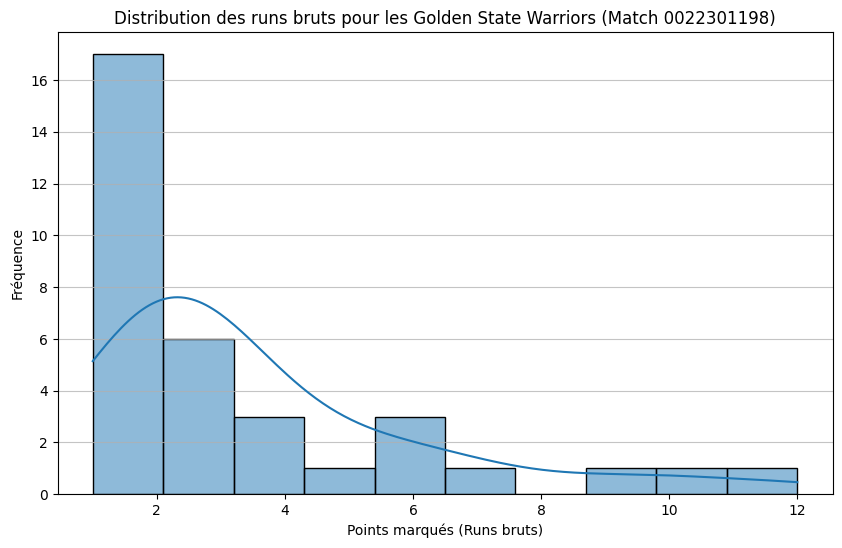

In [15]:
team_gsw_id = gsw["id"]
raw_runs_gsw, weighted_runs_gsw = get_team_runs(team_gsw_id, GAME_ID, df_games)

plt.figure(figsize=(10, 6))
sns.histplot(raw_runs_gsw['pts'], bins=10, kde=True)
plt.title(f'Distribution des runs bruts pour les {gsw["full_name"]} (Match {GAME_ID})')
plt.xlabel('Points marqués (Runs bruts)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [16]:
def get_team_runs_for_season(team_id, season):
    """
    Récupère l'ensemble des runs (bruts et pondérés) pour une équipe donnée
    sur une saison entière.

    Args:
        team_id (int): L'ID de l'équipe.
        season (str): La saison (par exemple, '2023-24').

    Returns:
        tuple: Deux DataFrames (all_raw_runs_season, all_weighted_runs_season).
               all_raw_runs_season: Tous les runs bruts faits par l'équipe sur la saison.
               all_weighted_runs_season: Tous les runs pondérés faits par l'équipe sur la saison.
    """

    print(f"Récupération des matchs pour la saison {season} et l'équipe {team_id}...")
    df_games_season = get_games_played(team_id, season)

    if df_games_season.empty:
        print(f"Aucun match trouvé pour la saison {season} et l'équipe {team_id}.")
        return pd.DataFrame(), pd.DataFrame()

    all_raw_runs_list = []
    all_weighted_runs_list = []

    num_games = len(df_games_season)
    for i, game_id in enumerate(df_games_season['Game_ID']):
        print(f"Traitement du match {i+1}/{num_games}: {game_id}...")
        # Pass df_games_season to get_team_runs
        raw_runs_game, weighted_runs_game = get_team_runs(team_id, game_id, df_games_season)

        # Add gameId to the runs DataFrames before appending
        if not raw_runs_game.empty:
            raw_runs_game['gameId'] = game_id
            all_raw_runs_list.append(raw_runs_game)
        if not weighted_runs_game.empty:
            weighted_runs_game['gameId'] = game_id
            all_weighted_runs_list.append(weighted_runs_game)

        # Petite pause pour éviter le blocage de l'API
        time.sleep(SLEEP)

    if all_raw_runs_list:
        all_raw_runs_season = pd.concat(all_raw_runs_list, ignore_index=True)
    else:
        all_raw_runs_season = pd.DataFrame()

    if all_weighted_runs_list:
        all_weighted_runs_season = pd.concat(all_weighted_runs_list, ignore_index=True)
    else:
        all_weighted_runs_season = pd.DataFrame()

    return all_raw_runs_season, all_weighted_runs_season

# Exemple d'utilisation :
team_id_gsw = gsw["id"]
season_to_analyze = "2023-24"

all_raw_runs_gsw_season, all_weighted_runs_gsw_season = get_team_runs_for_season(
    team_id_gsw, season_to_analyze
)

print(f"\nNombre total de runs bruts pour les GSW en {season_to_analyze} : {len(all_raw_runs_gsw_season)}")
print(all_raw_runs_gsw_season.head())

print(f"\nNombre total de runs pondérés pour les GSW en {season_to_analyze} : {len(all_weighted_runs_gsw_season)}")
print(all_weighted_runs_gsw_season.head())

Récupération des matchs pour la saison 2023-24 et l'équipe 1610612744...
Traitement du match 1/82: 0022301198...
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Traitement du match 2/82: 0022301182...
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personI

### Qu'est-ce qu'un "long run" ?

En se basant sur l'histogramme de la distribution des runs bruts pour les Golden State Warriors sur la saison 2023-24, un "long run" peut être défini comme un run avec un nombre de points nettement supérieur à la moyenne et dont la fréquence est plus faible.

Visuellement, la majeure partie des runs se situent dans la partie gauche de l'histogramme (runs plus courts). Les "longs runs" correspondent aux valeurs dans la queue droite de la distribution, c'est-à-dire les barres les moins hautes vers les points les plus élevés.

Par exemple, des runs de 10 points ou plus pourraient être considérés comme des "longs runs" car ils représentent des événements moins fréquents et plus extrêmes par rapport à l'ensemble des runs enregistrés. La détermination exacte du seuil pour un "long run" est souvent contextuelle et peut être affinée par des méthodes statistiques comme la Théorie des Valeurs Extrêmes (Extreme Value Theory) pour identifier formellement les événements rares et significatifs.

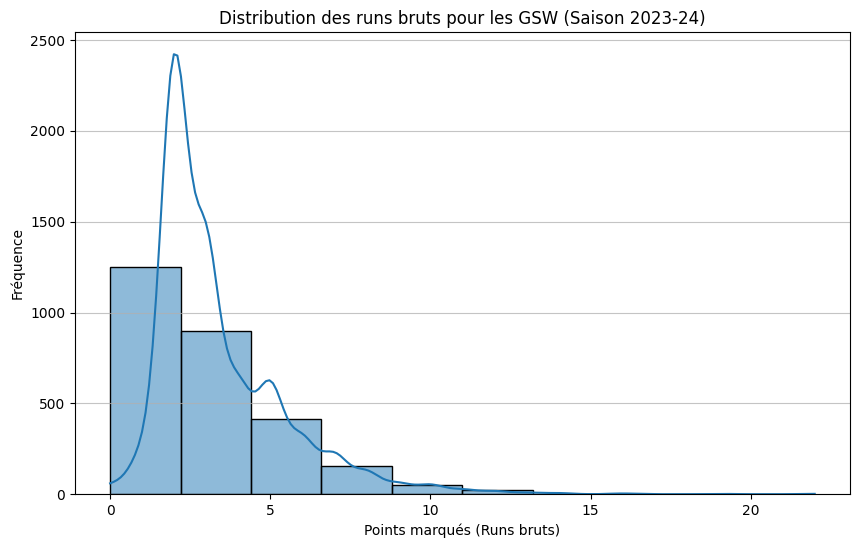

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(all_raw_runs_gsw_season['pts'], bins=10, kde=True)
plt.title(f'Distribution des runs bruts pour les GSW (Saison {season_to_analyze})')
plt.xlabel('Points marqués (Runs bruts)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [18]:
long_run_threshold = 10

total_raw_runs = len(all_raw_runs_gsw_season)
long_runs = all_raw_runs_gsw_season[all_raw_runs_gsw_season['pts'] >= long_run_threshold]
num_long_runs = len(long_runs)

probability_long_run = num_long_runs / total_raw_runs if total_raw_runs > 0 else 0

print(f"Total des runs bruts pour la saison: {total_raw_runs}")
print(f"Nombre de 'longs runs' (>= {long_run_threshold} points): {num_long_runs}")
print(f"Probabilité d'avoir un 'long run': {probability_long_run:.4f}")

Total des runs bruts pour la saison: 2802
Nombre de 'longs runs' (>= 10 points): 55
Probabilité d'avoir un 'long run': 0.0196


## Loi des runs

Deviner la loi

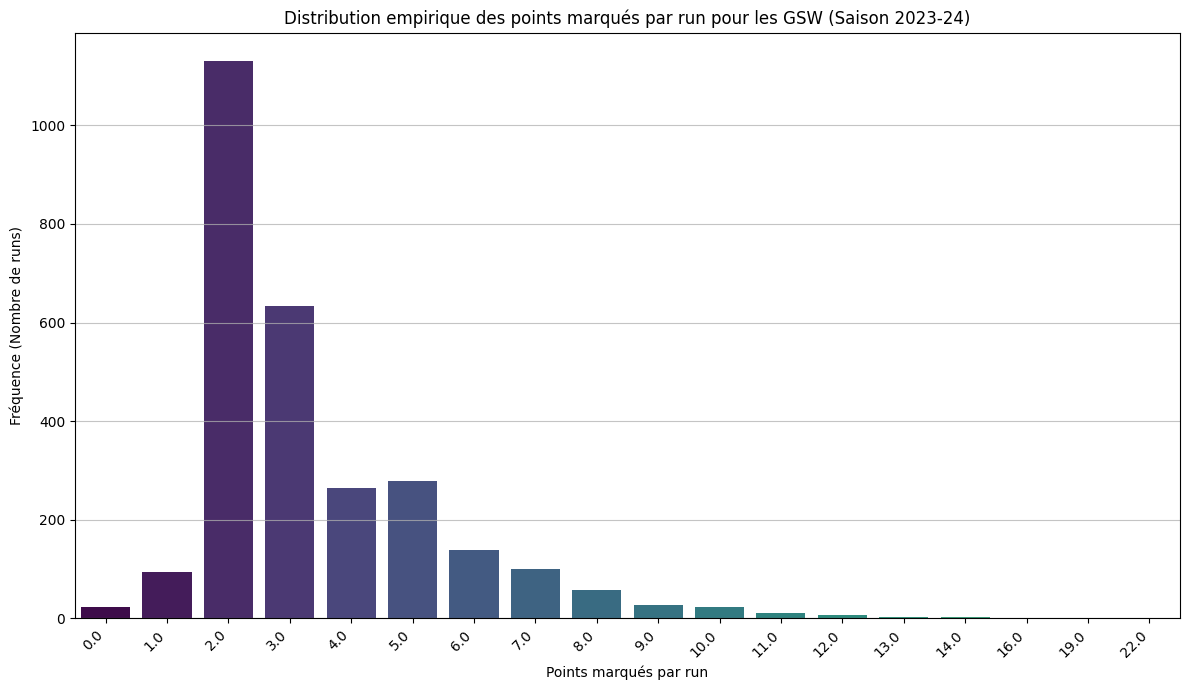

Descriptive statistics for points per run:
count    2802.000000
mean        3.414347
std         2.083747
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: pts, dtype: float64


In [19]:
plt.figure(figsize=(12, 7))
run_points_counts = all_raw_runs_gsw_season['pts'].value_counts().sort_index()
sns.barplot(x=run_points_counts.index, y=run_points_counts.values, palette='viridis', hue=run_points_counts.index, legend=False)
plt.title(f'Distribution empirique des points marqués par run pour les GSW (Saison {season_to_analyze})')
plt.xlabel('Points marqués par run')
plt.ylabel('Fréquence (Nombre de runs)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

print("Descriptive statistics for points per run:")
print(all_raw_runs_gsw_season['pts'].describe())

Nombre de 'longs runs' (>= 10 points) : 55

Paramètres de la distribution GEV ajustée :
  c (paramètre de forme) : -2.0632
  loc (paramètre de localisation) : 10.0000
  scale (paramètre d'échelle) : 0.0000


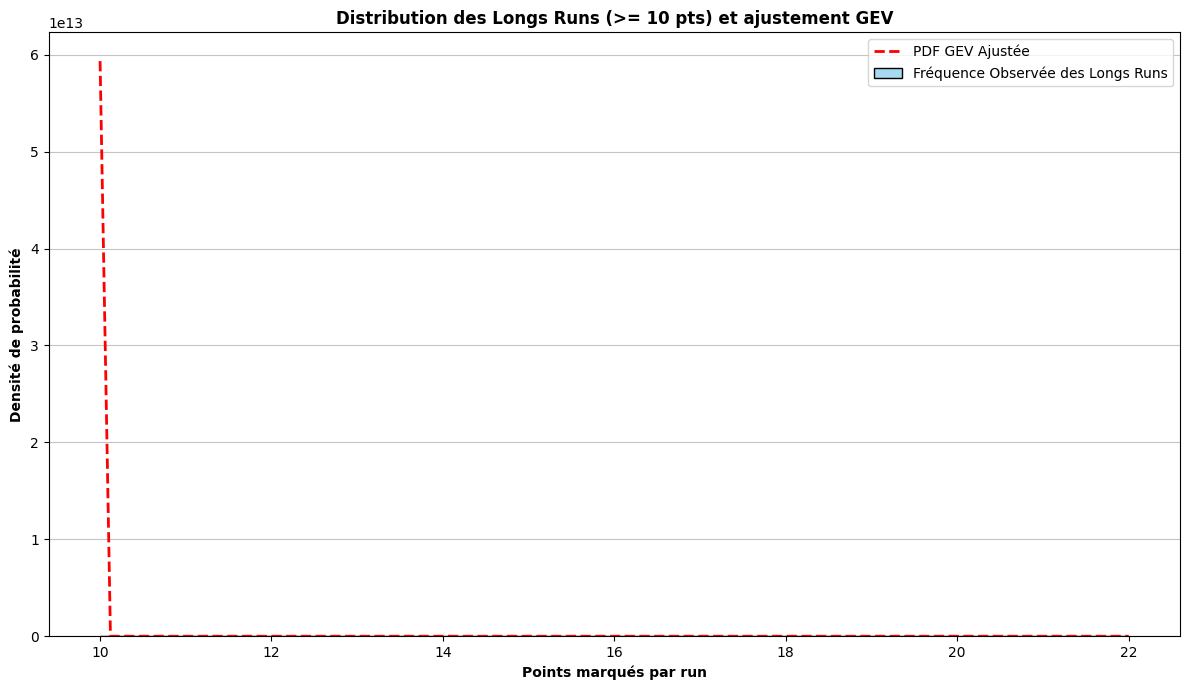

In [20]:
# Récupérer les 'longs runs' définis précédemment (>= long_run_threshold points)
long_run_threshold = 10 # Seuil défini précédemment
extreme_runs_data = all_raw_runs_gsw_season[all_raw_runs_gsw_season['pts'] >= long_run_threshold]['pts']

if extreme_runs_data.empty:
    print(f"Aucun run n'atteint le seuil de {long_run_threshold} points. Impossible d'ajuster une distribution GEV.")
else:
    print(f"Nombre de 'longs runs' (>= {long_run_threshold} points) : {len(extreme_runs_data)}")

    # Ajuster la distribution GEV aux données des 'longs runs'
    # La fonction fit_gev_distribution est supposée être définie dans utils_
    c, loc, scale = fit_gev_distribution(extreme_runs_data)

    print(f"\nParamètres de la distribution GEV ajustée :")
    print(f"  c (paramètre de forme) : {c:.4f}")
    print(f"  loc (paramètre de localisation) : {loc:.4f}")
    print(f"  scale (paramètre d'échelle) : {scale:.4f}")

    # Visualisation de l'ajustement GEV
    plt.figure(figsize=(12, 7))
    sns.histplot(extreme_runs_data, bins=max(1, len(extreme_runs_data)//2), kde=False, stat='density', color='skyblue', label='Fréquence Observée des Longs Runs')

    # Superposer la PDF de la distribution GEV ajustée
    x_vals = np.linspace(extreme_runs_data.min(), extreme_runs_data.max(), 100)
    pdf_gev = genextreme.pdf(x_vals, c, loc=loc, scale=scale)
    plt.plot(x_vals, pdf_gev, color='red', linestyle='--', linewidth=2, label='PDF GEV Ajustée')

    plt.title(f'Distribution des Longs Runs (>= {long_run_threshold} pts) et ajustement GEV', fontweight='bold')
    plt.xlabel('Points marqués par run', fontweight='bold')
    plt.ylabel('Densité de probabilité', fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

### Équation de la Distribution des Valeurs Extrêmes Généralisée (GEV)

La fonction de densité de probabilité (PDF) de la distribution GEV dépend de trois paramètres : la forme ($c$), la localisation ($\mu$), et l'échelle ($\sigma$).

L'équation générale de la GEV est :

$$ f(x; c, \mu, \sigma) = \frac{1}{\sigma} \exp\left( -\left( 1 + c \frac{x - \mu}{\sigma} \right)^{-1/c} \right) \left( 1 + c \frac{x - \mu}{\sigma} \right)^{-1 - 1/c} $$

Cette équation est valide pour $1 + c \frac{x - \mu}{\sigma} > 0$.

*   **$c$ (Shape Parameter)**: Détermine la forme de la queue de la distribution. Un $c=0$ correspond à la distribution de Gumbel, $c>0$ à la distribution de Fréchet, et $c<0$ à la distribution de Weibull inverse.
*   **$\mu$ (Location Parameter)**: Indique le centre de la distribution.
*   **$\sigma$ (Scale Parameter)**: Détermine la dispersion des données.

Les valeurs de $c$, $\mu$ (loc), et $\sigma$ (scale) que nous avons obtenues par ajustement sont affichées ci-dessus. Ce modèle est plus approprié pour caractériser le comportement des événements extrêmes.

## Indépendance des runs

Aperçu des données de runs avec durées :
          gameId SCORER  pts  duration  start_min   end_min
2601  0022300005    GSW  3.0  0.233333   0.466667  0.466667
2602  0022300005    GSW  2.0  0.208333   0.950000  0.950000
2603  0022300005    GSW  3.0  0.200000   1.333333  1.333333
2604  0022300005    GSW  4.0  0.675000   2.883333  3.216667
2605  0022300005    GSW  6.0  0.641667   4.483333  5.000000

--- Analyse de l'autocorrélation pour les points marqués (pts) ---


<Figure size 1200x600 with 0 Axes>

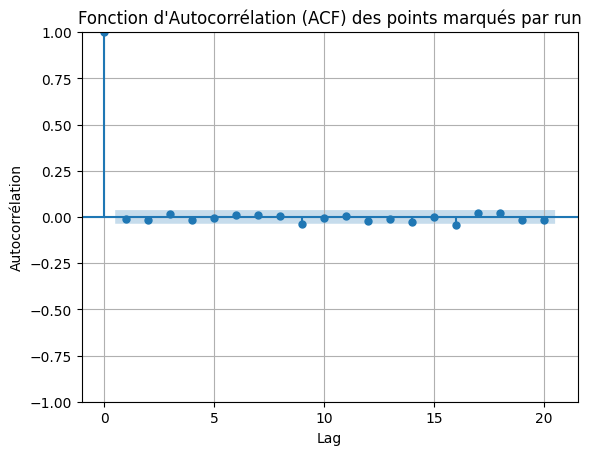

Résultats du test de Ljung-Box pour les points marqués :
     lb_stat  lb_pvalue
1   0.219734   0.639243
5   3.025976   0.695981
10  7.666983   0.661329

--- Analyse de l'autocorrélation pour la durée des runs ---


<Figure size 1200x600 with 0 Axes>

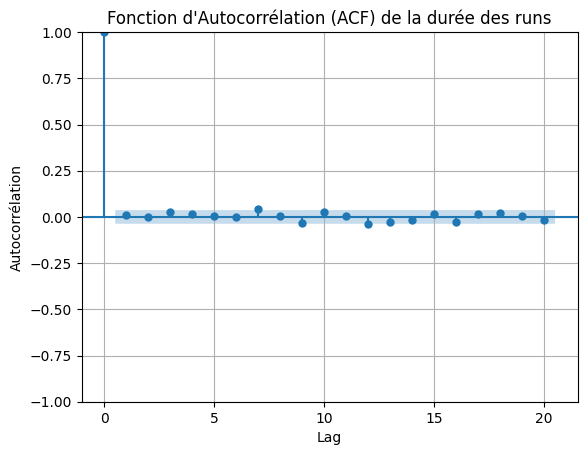

Résultats du test de Ljung-Box pour la durée des runs :
      lb_stat  lb_pvalue
1    0.262340   0.608517
5    3.485716   0.625550
10  14.144070   0.166521

--- Interprétation ---
Pour considérer les runs comme indépendants, nous nous attendons à ce que les valeurs d'autocorrélation restent dans la zone bleue (intervalle de confiance) sur les graphes ACF, et que les p-values du test de Ljung-Box soient supérieures à notre seuil de significativité (par exemple, 0.05).
Si les p-values sont inférieures à 0.05, cela suggère la présence d'autocorrélation, remettant en question l'indépendance.


In [19]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Assurer que les runs sont triés par Game_ID et start_min pour maintenir l'ordre temporel
all_raw_runs_gsw_season_sorted = all_raw_runs_gsw_season.sort_values(by=['gameId', 'start_min']).copy()

# Le calcul de la durée du run est maintenant inclus dans point_filter1.
# Donc, cette ligne n'est plus nécessaire ici.
# all_raw_runs_gsw_season_sorted['duration'] = all_raw_runs_gsw_season_sorted['end_min'] - all_raw_runs_gsw_season_sorted['start_min']

print("Aperçu des données de runs avec durées :")
print(all_raw_runs_gsw_season_sorted[['gameId', 'SCORER', 'pts', 'duration', 'start_min', 'end_min']].head())

# --- Test d'autocorrélation pour les points marqués (pts) ---
print("\n--- Analyse de l'autocorrélation pour les points marqués (pts) ---")
# Plot ACF for points
plt.figure(figsize=(12, 6))
plot_acf(all_raw_runs_gsw_season_sorted['pts'], lags=20, alpha=0.05)
plt.title('Fonction d\'Autocorrélation (ACF) des points marqués par run')
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.grid(True)
plt.show()

# Ljung-Box test for points
# Set `return_df=True` to get results in a DataFrame
ljung_box_pts_results = acorr_ljungbox(all_raw_runs_gsw_season_sorted['pts'], lags=[1, 5, 10], return_df=True)
print("Résultats du test de Ljung-Box pour les points marqués :")
print(ljung_box_pts_results)

# --- Test d'autocorrélation pour la durée des runs (duration) ---
print("\n--- Analyse de l'autocorrélation pour la durée des runs ---")
# Plot ACF for duration
plt.figure(figsize=(12, 6))
plot_acf(all_raw_runs_gsw_season_sorted['duration'], lags=20, alpha=0.05)
plt.title('Fonction d\'Autocorrélation (ACF) de la durée des runs')
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.grid(True)
plt.show()

# Ljung-Box test for duration
ljung_box_duration_results = acorr_ljungbox(all_raw_runs_gsw_season_sorted['duration'], lags=[1, 5, 10], return_df=True)
print("Résultats du test de Ljung-Box pour la durée des runs :")
print(ljung_box_duration_results)

print("\n--- Interprétation ---")
print("Pour considérer les runs comme indépendants, nous nous attendons à ce que les valeurs d'autocorrélation restent dans la zone bleue (intervalle de confiance) sur les graphes ACF, et que les p-values du test de Ljung-Box soient supérieures à notre seuil de significativité (par exemple, 0.05).")
print("Si les p-values sont inférieures à 0.05, cela suggère la présence d'autocorrélation, remettant en question l'indépendance.")


### Récupération et comparaison des runs pour une autre saison (2022-23)

In [22]:
season_to_analyze_prev = "2022-23"
team_id_gsw = gsw["id"]

print(f"Récupération des runs pour les GSW en {season_to_analyze_prev}...")
all_raw_runs_gsw_season_prev, all_weighted_runs_gsw_season_prev = get_team_runs_for_season(
    team_id_gsw, season_to_analyze_prev
)

print(f"\nNombre total de runs bruts pour les GSW en {season_to_analyze_prev} : {len(all_raw_runs_gsw_season_prev)}")
print(all_raw_runs_gsw_season_prev.head())

print(f"\nNombre total de runs pondérés pour les GSW en {season_to_analyze_prev} : {len(all_weighted_runs_gsw_season_prev)}")
print(all_weighted_runs_gsw_season_prev.head())

Récupération des runs pour les GSW en 2022-23...
Récupération des matchs pour la saison 2022-23 et l'équipe 1610612744...
Traitement du match 1/82: 0022201230...
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 474
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Traitement du match 2/82: 0022201211...
Nombre d'actions : 505
Colonnes disponibles : ['gameId', 'actionNumber', 'cl

### Comparaison visuelle des distributions de runs bruts (2023-24 vs 2022-23)

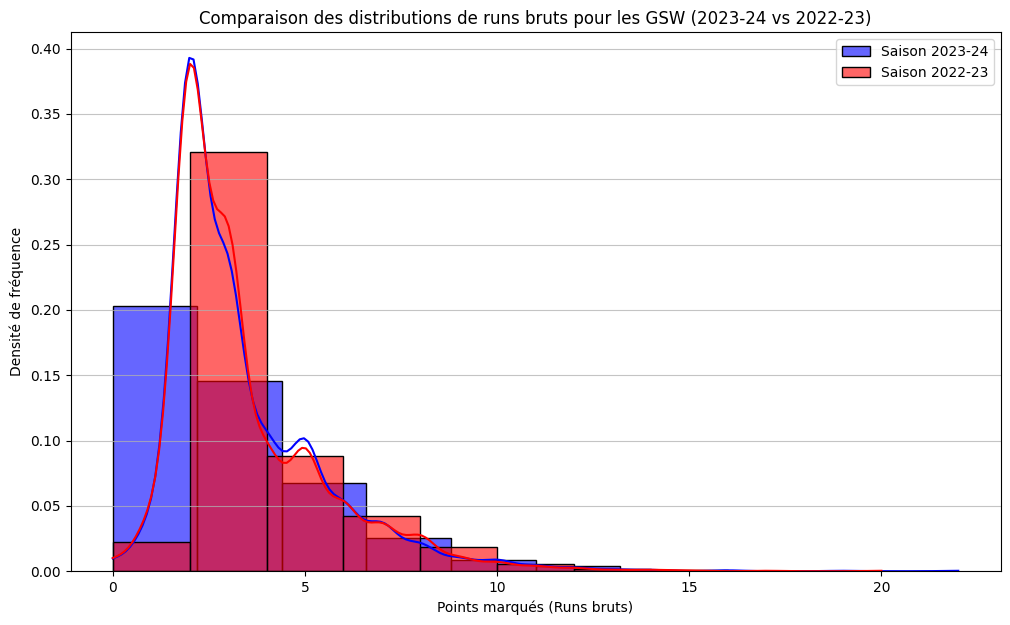

In [23]:
plt.figure(figsize=(12, 7))
sns.histplot(all_raw_runs_gsw_season['pts'], bins=10, kde=True, color='blue', label=f'Saison {season_to_analyze}', stat='density', alpha=0.6)
sns.histplot(all_raw_runs_gsw_season_prev['pts'], bins=10, kde=True, color='red', label=f'Saison {season_to_analyze_prev}', stat='density', alpha=0.6)
plt.title(f'Comparaison des distributions de runs bruts pour les GSW ({season_to_analyze} vs {season_to_analyze_prev})')
plt.xlabel('Points marqués (Runs bruts)')
plt.ylabel('Densité de fréquence')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

### Évaluation de l'indépendance des runs pour la saison 2022-23

Aperçu des données de runs avec durées pour la saison 2022-23 :
          gameId SCORER  pts  duration  start_min   end_min
2805  0022200002    GSW  5.0  1.850000   1.016667  2.700000
2806  0022200002    GSW  4.0  0.683333   3.516667  4.066667
2807  0022200002    GSW  2.0  0.050000   4.633333  4.633333
2808  0022200002    GSW  3.0  0.283333   5.550000  5.550000
2809  0022200002    GSW  5.0  0.466667   5.966667  6.316667

--- Analyse de l'autocorrélation pour les points marqués (pts) - Saison 2022-23 ---


<Figure size 1200x600 with 0 Axes>

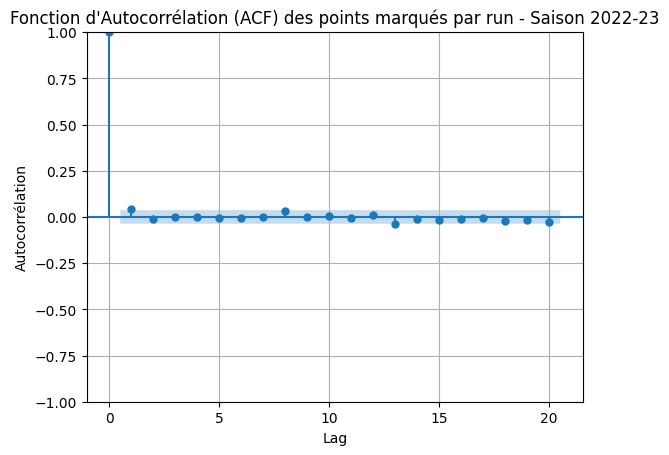

Résultats du test de Ljung-Box pour les points marqués - Saison 2022-23 :
     lb_stat  lb_pvalue
1   4.772962   0.028910
5   5.065577   0.407930
10  8.571007   0.573241

--- Analyse de l'autocorrélation pour la durée des runs - Saison 2022-23 ---


<Figure size 1200x600 with 0 Axes>

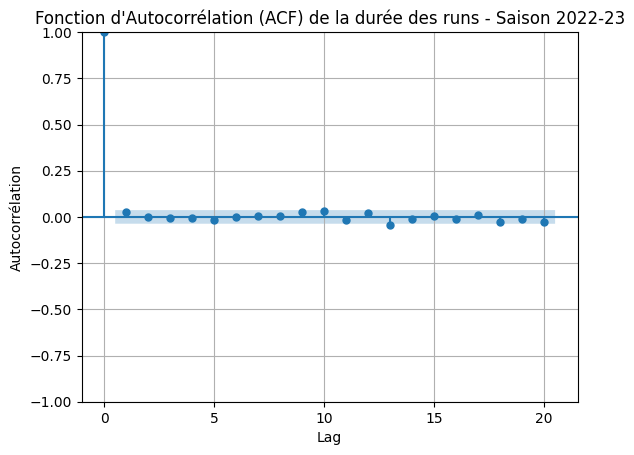

Résultats du test de Ljung-Box pour la durée des runs - Saison 2022-23 :
     lb_stat  lb_pvalue
1   2.416579   0.120057
5   3.432936   0.633559
10  8.406225   0.589222

--- Interprétation Générale ---
Pour les deux saisons, nous allons examiner si les valeurs d'autocorrélation sur les graphes ACF restent dans la zone bleue et si les p-values du test de Ljung-Box sont supérieures à 0.05. Si c'est le cas, cela supportera l'hypothèse que les runs sont indépendants au fil du temps au sein de chaque saison.


In [24]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Assurer que les runs sont triés par Game_ID et start_min pour maintenir l'ordre temporel
all_raw_runs_gsw_season_prev_sorted = all_raw_runs_gsw_season_prev.sort_values(by=['gameId', 'start_min']).copy()

# Le calcul de la durée du run est maintenant inclus dans point_filter1.
# Donc, cette ligne n'est plus nécessaire ici.
# all_raw_runs_gsw_season_prev_sorted['duration'] = all_raw_runs_gsw_season_prev_sorted['end_min'] - all_raw_runs_gsw_season_prev_sorted['start_min']

print("Aperçu des données de runs avec durées pour la saison 2022-23 :")
print(all_raw_runs_gsw_season_prev_sorted[['gameId', 'SCORER', 'pts', 'duration', 'start_min', 'end_min']].head())

# --- Test d'autocorrélation pour les points marqués (pts) - Saison 2022-23 ---
print(f"\n--- Analyse de l'autocorrélation pour les points marqués (pts) - Saison {season_to_analyze_prev} ---")
# Plot ACF for points
plt.figure(figsize=(12, 6))
plot_acf(all_raw_runs_gsw_season_prev_sorted['pts'], lags=20, alpha=0.05)
plt.title(f'Fonction d\'Autocorrélation (ACF) des points marqués par run - Saison {season_to_analyze_prev}')
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.grid(True)
plt.show()

# Ljung-Box test for points
ljung_box_pts_results_prev = acorr_ljungbox(all_raw_runs_gsw_season_prev_sorted['pts'], lags=[1, 5, 10], return_df=True)
print(f"Résultats du test de Ljung-Box pour les points marqués - Saison {season_to_analyze_prev} :")
print(ljung_box_pts_results_prev)

# --- Test d'autocorrélation pour la durée des runs (duration) - Saison 2022-23 ---
print(f"\n--- Analyse de l'autocorrélation pour la durée des runs - Saison {season_to_analyze_prev} ---")
# Plot ACF for duration
plt.figure(figsize=(12, 6))
plot_acf(all_raw_runs_gsw_season_prev_sorted['duration'], lags=20, alpha=0.05)
plt.title(f'Fonction d\'Autocorrélation (ACF) de la durée des runs - Saison {season_to_analyze_prev}')
plt.xlabel('Lag')
plt.ylabel('Autocorrélation')
plt.grid(True)
plt.show()

# Ljung-Box test for duration
ljung_box_duration_results_prev = acorr_ljungbox(all_raw_runs_gsw_season_prev_sorted['duration'], lags=[1, 5, 10], return_df=True)
print(f"Résultats du test de Ljung-Box pour la durée des runs - Saison {season_to_analyze_prev} :")
print(ljung_box_duration_results_prev)

print("\n--- Interprétation Générale ---")
print("Pour les deux saisons, nous allons examiner si les valeurs d'autocorrélation sur les graphes ACF restent dans la zone bleue et si les p-values du test de Ljung-Box sont supérieures à 0.05. Si c'est le cas, cela supportera l'hypothèse que les runs sont indépendants au fil du temps au sein de chaque saison.")

# Partie II Etude des ecarts de points et Distribution des ecarts de points à l'issue d'un match

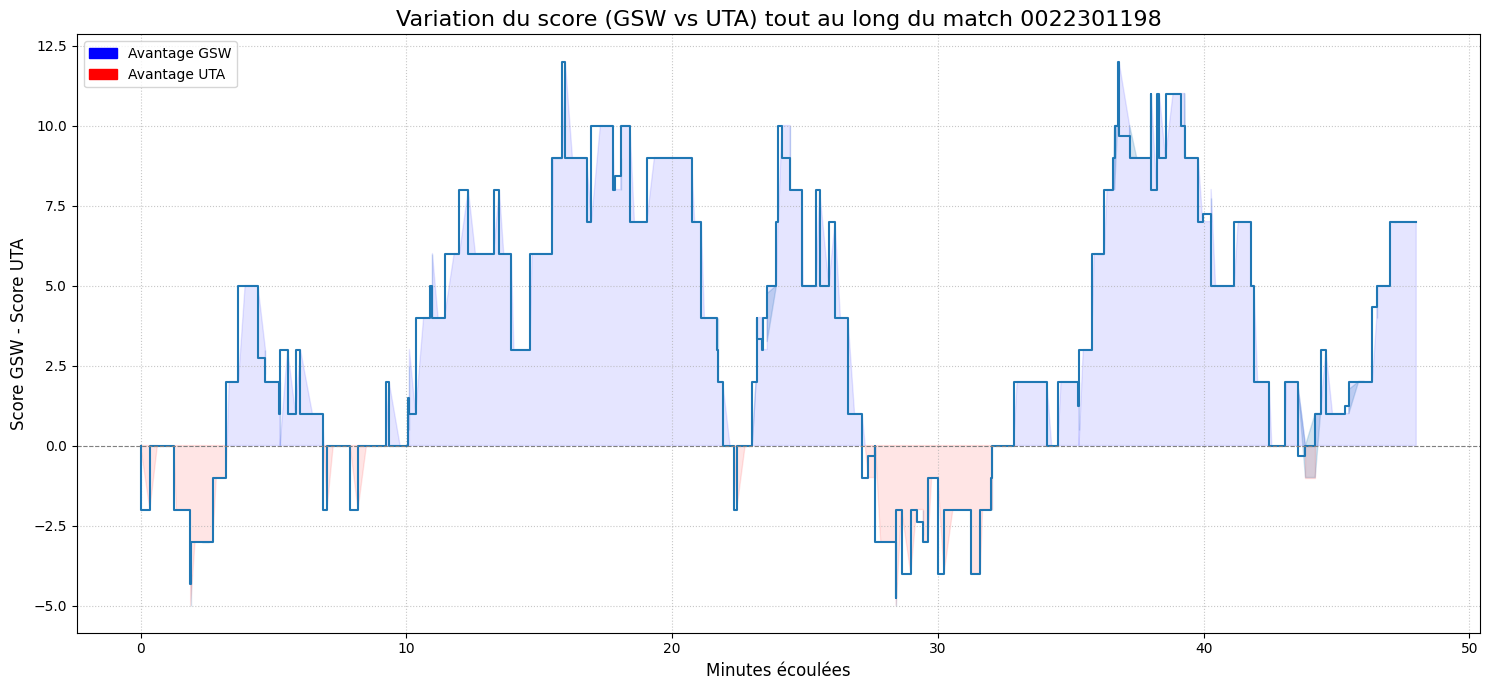

In [25]:
import re

# H1: Plot la variation des scores tout au long d'un match

plt.figure(figsize=(15, 7))
sns.lineplot(data=df, x='ELAPSED_MINUTES', y='SCOREMARGIN_FF', drawstyle='steps-pre')

# Retrieve the matchup string for the current game from df_games
matchup_string = df_games[df_games['Game_ID'] == GAME_ID]['MATCHUP'].iloc[0]

# Parse the matchup_string to correctly determine home_team_name and away_team_name
# Example: 'GSW vs. UTA' or 'GSW @ POR'
if 'vs.' in matchup_string:
    home_team_name = matchup_string.split(' vs. ')[0].strip()
    away_team_name = matchup_string.split(' vs. ')[1].strip()
elif '@' in matchup_string:
    away_team_name = matchup_string.split(' @ ')[0].strip()
    home_team_name = matchup_string.split(' @ ')[1].strip()
else:
    # Fallback for unexpected formats - use what's available from df_teams_box if parsing fails
    # Or, as a simpler fallback, just use default labels or raise an error
    home_team_name = df_teams_box.loc[0, 'TEAM_ABBREVIATION'] # Assuming first row is home team from PBP
    away_team_name = df_teams_box.loc[1, 'TEAM_ABBREVIATION'] # Assuming second row is away team from PBP

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title(f'Variation du score ({home_team_name} vs {away_team_name}) tout au long du match {GAME_ID}', fontsize=16)
plt.xlabel('Minutes écoulées', fontsize=12)
plt.ylabel(f'Score {home_team_name} - Score {away_team_name}', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Ajouter une légende pour indiquer qui est en avance
home_patch = mpatches.Patch(color='blue', label=f'Avantage {home_team_name}')
away_patch = mpatches.Patch(color='red', label=f'Avantage {away_team_name}')

# Créer des zones colorées pour montrer quelle équipe mène
# Utiliser l'axe y pour remplir la zone
plt.fill_between(df['ELAPSED_MINUTES'], df['SCOREMARGIN_FF'], 0,
                 where=(df['SCOREMARGIN_FF'] > 0), color='blue', alpha=0.1, interpolate=True)
plt.fill_between(df['ELAPSED_MINUTES'], df['SCOREMARGIN_FF'], 0,
                 where=(df['SCOREMARGIN_FF'] < 0), color='red', alpha=0.1, interpolate=True)

plt.legend(handles=[home_patch, away_patch], loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
from nba_api.stats.endpoints import teamgamelog, boxscoretraditionalv2
import pandas as pd
import numpy as np
import time

def get_games_played(team_id: int, season: str, sleep: float = 1.0) -> pd.DataFrame:
    """
    Récupère le log des matchs joués par une équipe pour une saison donnée,
    incluant les points de l'équipe et les points de l'adversaire,
    calculés à partir des données du gamelog ou des boxscores individuels si nécessaire.
    """
    print(f"Récupération des matchs pour l'équipe {team_id} en {season}...")
    gamelog = teamgamelog.TeamGameLog(season=season, team_id=team_id)
    df = gamelog.get_data_frames()[0]

    # Normalize column names to avoid subtle string issues (e.g., invisible characters)
    df.columns = [str(col).strip() for col in df.columns]

    # Debugging: Print all columns to identify what's actually returned
    print(f"Columns available from teamgamelog for team {team_id}, season {season}: {df.columns.tolist()}")

    # Check if 'PLUS_MINUS' is available. If not, we need a fallback.
    if 'PLUS_MINUS' not in df.columns:
        print(f"Avertissement: La colonne 'PLUS_MINUS' est manquante dans le gamelog. Récupération des scores via boxscore pour chaque match.")

        # Initialize OPP_PTS column with NaN
        df['OPP_PTS'] = np.nan

        # Iterate through games using df['Game_ID'].values and original index for robust access
        for i, game_id in enumerate(df['Game_ID'].values):
            original_index = df.index[i] # Get the original index to update df.loc
            try:
                boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
                teams_box = boxscore.get_data_frames()[1] # Team stats

                # Get the opponent's score for this game
                opponent_score = teams_box[teams_box['TEAM_ID'] != team_id]['PTS'].iloc[0]

                df.loc[original_index, 'OPP_PTS'] = opponent_score
            except Exception as e:
                print(f"Erreur lors de la récupération du boxscore pour le match {game_id}: {e}")
                df.loc[original_index, 'OPP_PTS'] = np.nan # Mark as missing if error occurs
            time.sleep(sleep) # Be nice to the API

    else:
        # If 'PLUS_MINUS' is available, calculate OPP_PTS as before
        df['OPP_PTS'] = df['PTS'] - df['PLUS_MINUS']

    # Ensure all required columns are present after processing
    required_columns_final = ['Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'PTS', 'OPP_PTS'] # Corrected 'GAME_ID' to 'Game_ID'
    if not all(col in df.columns for col in required_columns_final):
        missing_cols = [col for col in required_columns_final if col not in df.columns]
        raise KeyError(f"Colonnes finales manquantes après traitement: {missing_cols}. Colonnes disponibles: {df.columns.tolist()}")

    return df

# Re-fetch df_games using the corrected function
SEASON = "2023-24"
TEAM_ID = gsw["id"] # Golden State Warriors
# Pass the global SLEEP variable, or use the default 1.0 if it's not defined globally.
df_games = get_games_played(TEAM_ID, SEASON, sleep=SLEEP if 'SLEEP' in globals() else 1.0)

print(f"Matchs récupérés (avec OPP_PTS) : {len(df_games)}")
print(df_games[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS", "OPP_PTS"]].head(10))

Récupération des matchs pour l'équipe 1610612744 en 2023-24...
Columns available from teamgamelog for team 1610612744, season 2023-24: ['Team_ID', 'Game_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']
Avertissement: La colonne 'PLUS_MINUS' est manquante dans le gamelog. Récupération des scores via boxscore pour chaque match.


/tmp/ipykernel_56712/3342991372.py:33: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
/tmp/ipykernel_56712/3342991372.py:33: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTraditionalV2(game_id=game_id)
/tmp/ipykernel_56712/3342991372.py:33: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  boxscore = boxscoretraditionalv2.BoxScoreTradi

Matchs récupérés (avec OPP_PTS) : 82
      Game_ID     GAME_DATE      MATCHUP WL  PTS  OPP_PTS
0  0022301198  APR 14, 2024  GSW vs. UTA  W  123    116.0
1  0022301182  APR 12, 2024  GSW vs. NOP  L  109    114.0
2  0022301169  APR 11, 2024    GSW @ POR  W  100     92.0
3  0022301155  APR 09, 2024    GSW @ LAL  W  134    120.0
4  0022301142  APR 07, 2024  GSW vs. UTA  W  118    110.0
5  0022301097  APR 05, 2024    GSW @ DAL  L  106    108.0
6  0022301113  APR 04, 2024    GSW @ HOU  W  133    110.0
7  0022300589  APR 02, 2024  GSW vs. DAL  W  104    100.0
8  0022301085  MAR 31, 2024    GSW @ SAS  W  117    113.0
9  0022301062  MAR 29, 2024    GSW @ CHA  W  115     97.0


In [27]:
def calculate_final_score_difference(row):
    """
    Calculates the final score difference (Home Team Score - Away Team Score)
    based on the matchup string and the selected team's points.
    """
    if "vs." in row['MATCHUP']:
        # Selected team was home, so PTS is home score, OPP_PTS is away score
        return row['PTS'] - row['OPP_PTS']
    elif "@" in row['MATCHUP']:
        # Selected team was away, so OPP_PTS is home score, PTS is away score
        return row['OPP_PTS'] - row['PTS']
    return np.nan # Should not happen with valid matchup strings

# Apply the function to calculate the final score difference for each game
df_games['FINAL_SCORE_DIFF'] = df_games.apply(calculate_final_score_difference, axis=1)

print("First 10 games with calculated final score difference:")
print(df_games[['GAME_DATE', 'MATCHUP', 'PTS', 'OPP_PTS', 'FINAL_SCORE_DIFF']].head(10))

First 10 games with calculated final score difference:
      GAME_DATE      MATCHUP  PTS  OPP_PTS  FINAL_SCORE_DIFF
0  APR 14, 2024  GSW vs. UTA  123    116.0               7.0
1  APR 12, 2024  GSW vs. NOP  109    114.0              -5.0
2  APR 11, 2024    GSW @ POR  100     92.0              -8.0
3  APR 09, 2024    GSW @ LAL  134    120.0             -14.0
4  APR 07, 2024  GSW vs. UTA  118    110.0               8.0
5  APR 05, 2024    GSW @ DAL  106    108.0               2.0
6  APR 04, 2024    GSW @ HOU  133    110.0             -23.0
7  APR 02, 2024  GSW vs. DAL  104    100.0               4.0
8  MAR 31, 2024    GSW @ SAS  117    113.0              -4.0
9  MAR 29, 2024    GSW @ CHA  115     97.0             -18.0


## H2 : Distribution des scores en valeur absolue en fin de match -> Définir "blowout"
## H3 : Etude des blowouts (distribution avec l'EVT)

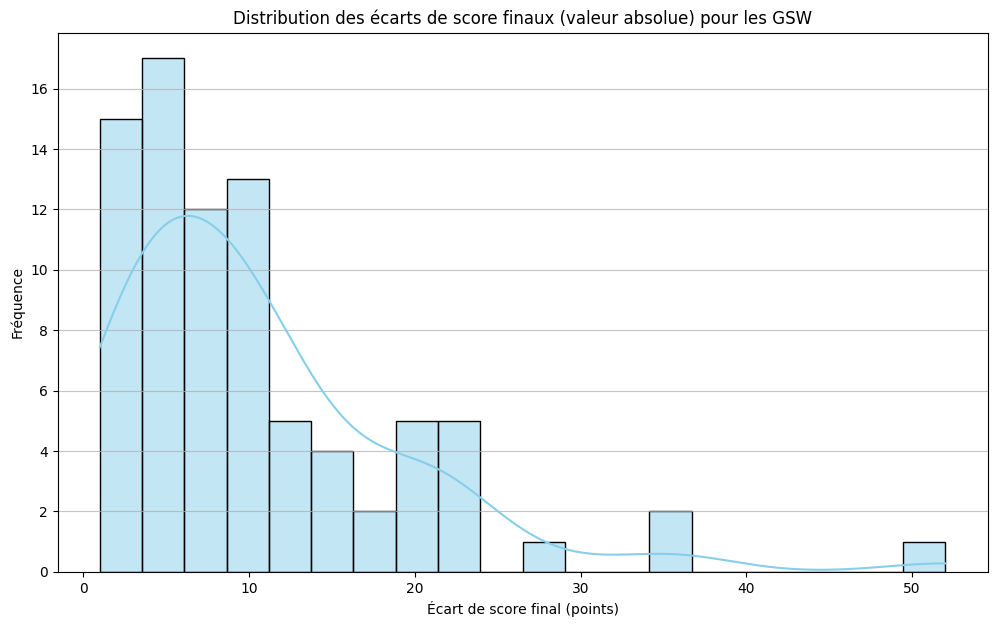

Statistiques descriptives pour les écarts de score finaux (valeur absolue):
count    82.000000
mean     10.512195
std       8.912807
min       1.000000
25%       4.000000
50%       8.000000
75%      13.000000
max      52.000000
Name: ABS_FINAL_SCORE_DIFF, dtype: float64

Seuil de 'blowout' (90ème percentile) : 21.90 points
Seuil de 'blowout' (fixe) : 15 points

Nombre de 'blowouts' (au-dessus de 21.90 points) : 9

Paramètres de la distribution GPD ajustée :
  c (paramètre de forme) : 5.6727
  loc (seuil) : 22.0000
  scale (paramètre d'échelle) : 0.0000


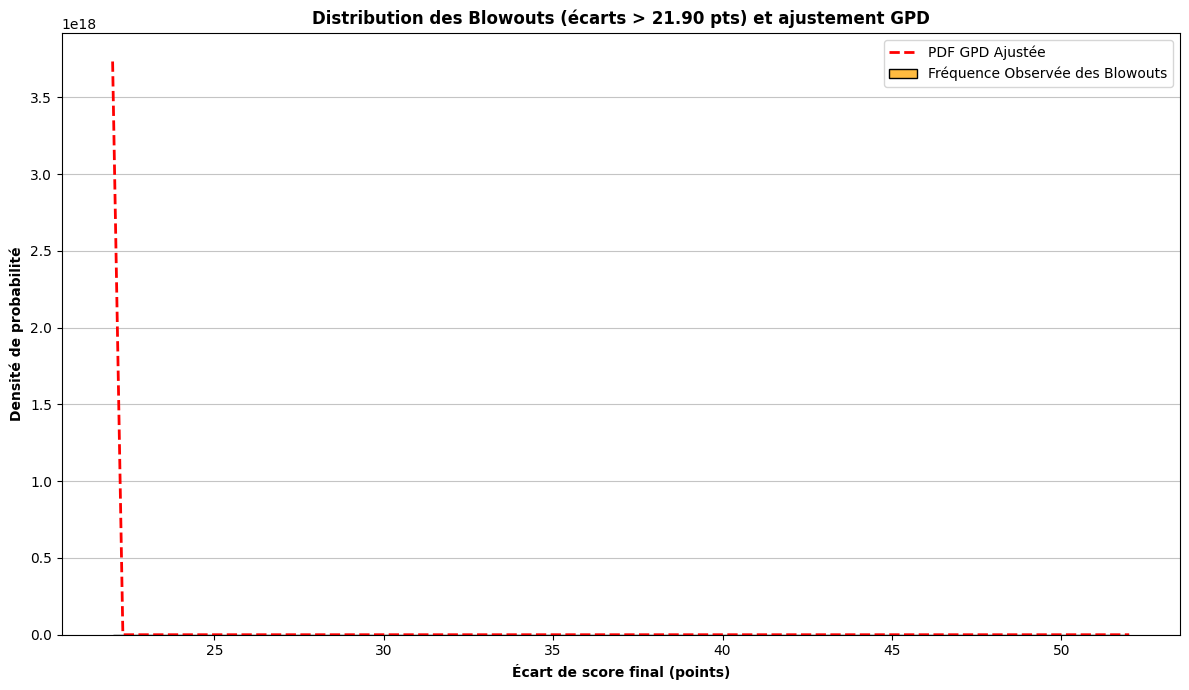

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto # Generalized Pareto Distribution for POT method

# Calculate absolute score difference for all games
df_games['ABS_FINAL_SCORE_DIFF'] = df_games['FINAL_SCORE_DIFF'].abs()

# --- H2: Distribution des scores en valeur absolue en fin de match ---
plt.figure(figsize=(12, 7))
sns.histplot(df_games['ABS_FINAL_SCORE_DIFF'], bins=20, kde=True, color='skyblue')
plt.title('Distribution des écarts de score finaux (valeur absolue) pour les GSW')
plt.xlabel('Écart de score final (points)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Statistiques descriptives pour les écarts de score finaux (valeur absolue):")
print(df_games['ABS_FINAL_SCORE_DIFF'].describe())

# Définition d'un "blowout" : Ici, nous allons définir un blowout comme un match
# où l'écart de score final est supérieur à un certain seuil. Pour la démonstration,
# nous pourrions choisir un seuil arbitraire, par exemple, le 75ème percentile ou une valeur fixe comme 15-20 points.

blowout_threshold_percentile = df_games['ABS_FINAL_SCORE_DIFF'].quantile(0.90)
print(f"\nSeuil de 'blowout' (90ème percentile) : {blowout_threshold_percentile:.2f} points")

blowout_threshold_fixed = 15 # Exemple de seuil fixe
print(f"Seuil de 'blowout' (fixe) : {blowout_threshold_fixed} points")

# --- H3: Etude des blowouts (distribution avec l'EVT) ---
# Utilisation de la méthode POT (Peaks Over Threshold) avec la distribution de Pareto Généralisée (GPD)
# pour modéliser les 'blowouts' qui sont au-dessus d'un certain seuil.

# Choisissons un seuil pour l'EVT. Ce seuil doit être suffisamment élevé pour capturer les extrêmes.
# Nous allons utiliser le 90ème percentile comme seuil initial pour la GPD.

threshold_evt = blowout_threshold_percentile # Ou une valeur fixe si désiré

blowout_data = df_games[df_games['ABS_FINAL_SCORE_DIFF'] > threshold_evt]['ABS_FINAL_SCORE_DIFF']

if blowout_data.empty:
    print(f"\nAucun blowout trouvé au-dessus du seuil de {threshold_evt:.2f} points. Impossible d'ajuster une distribution GPD.")
else:
    print(f"\nNombre de 'blowouts' (au-dessus de {threshold_evt:.2f} points) : {len(blowout_data)}")

    # Ajuster la distribution GPD aux données de blowout
    # Scipy gpareto utilise (c, loc, scale) où c est le paramètre de forme (xi), loc est le seuil (mu), et scale est beta.
    c_gpd, loc_gpd, scale_gpd = genpareto.fit(blowout_data, loc=threshold_evt)

    print(f"\nParamètres de la distribution GPD ajustée :")
    print(f"  c (paramètre de forme) : {c_gpd:.4f}")
    print(f"  loc (seuil) : {loc_gpd:.4f}")
    print(f"  scale (paramètre d'échelle) : {scale_gpd:.4f}")

    # Visualisation de l'ajustement GPD
    plt.figure(figsize=(12, 7))
    sns.histplot(blowout_data, bins=max(1, len(blowout_data)//2), kde=False, stat='density', color='orange', label='Fréquence Observée des Blowouts')

    # Superposer la PDF de la distribution GPD ajustée
    x_vals_gpd = np.linspace(blowout_data.min(), blowout_data.max(), 100)
    pdf_gpd = genpareto.pdf(x_vals_gpd, c_gpd, loc=loc_gpd, scale=scale_gpd)
    plt.plot(x_vals_gpd, pdf_gpd, color='red', linestyle='--', linewidth=2, label='PDF GPD Ajustée')

    plt.title(f'Distribution des Blowouts (écarts > {threshold_evt:.2f} pts) et ajustement GPD', fontweight='bold')
    plt.xlabel('Écart de score final (points)', fontweight='bold')
    plt.ylabel('Densité de probabilité', fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

# Partie III : Distribution des longueurs temporelles des runs selon le nb de pts + vitesse

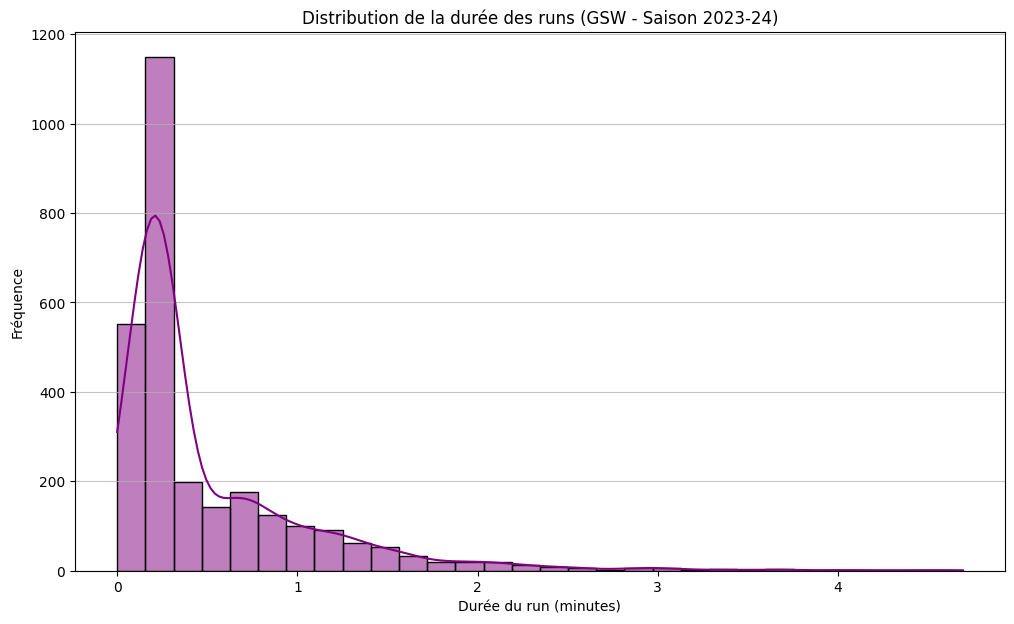

Statistiques descriptives pour la durée des runs:
count    2802.000000
mean        0.504411
std         0.570329
min         0.000000
25%         0.183333
50%         0.266667
75%         0.675000
max         4.691667
Name: duration, dtype: float64


In [29]:
plt.figure(figsize=(12, 7))
sns.histplot(all_raw_runs_gsw_season_sorted['duration'], bins=30, kde=True, color='purple')
plt.title(f'Distribution de la durée des runs (GSW - Saison {season_to_analyze})')
plt.xlabel('Durée du run (minutes)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Statistiques descriptives pour la durée des runs:")
print(all_raw_runs_gsw_season_sorted['duration'].describe())

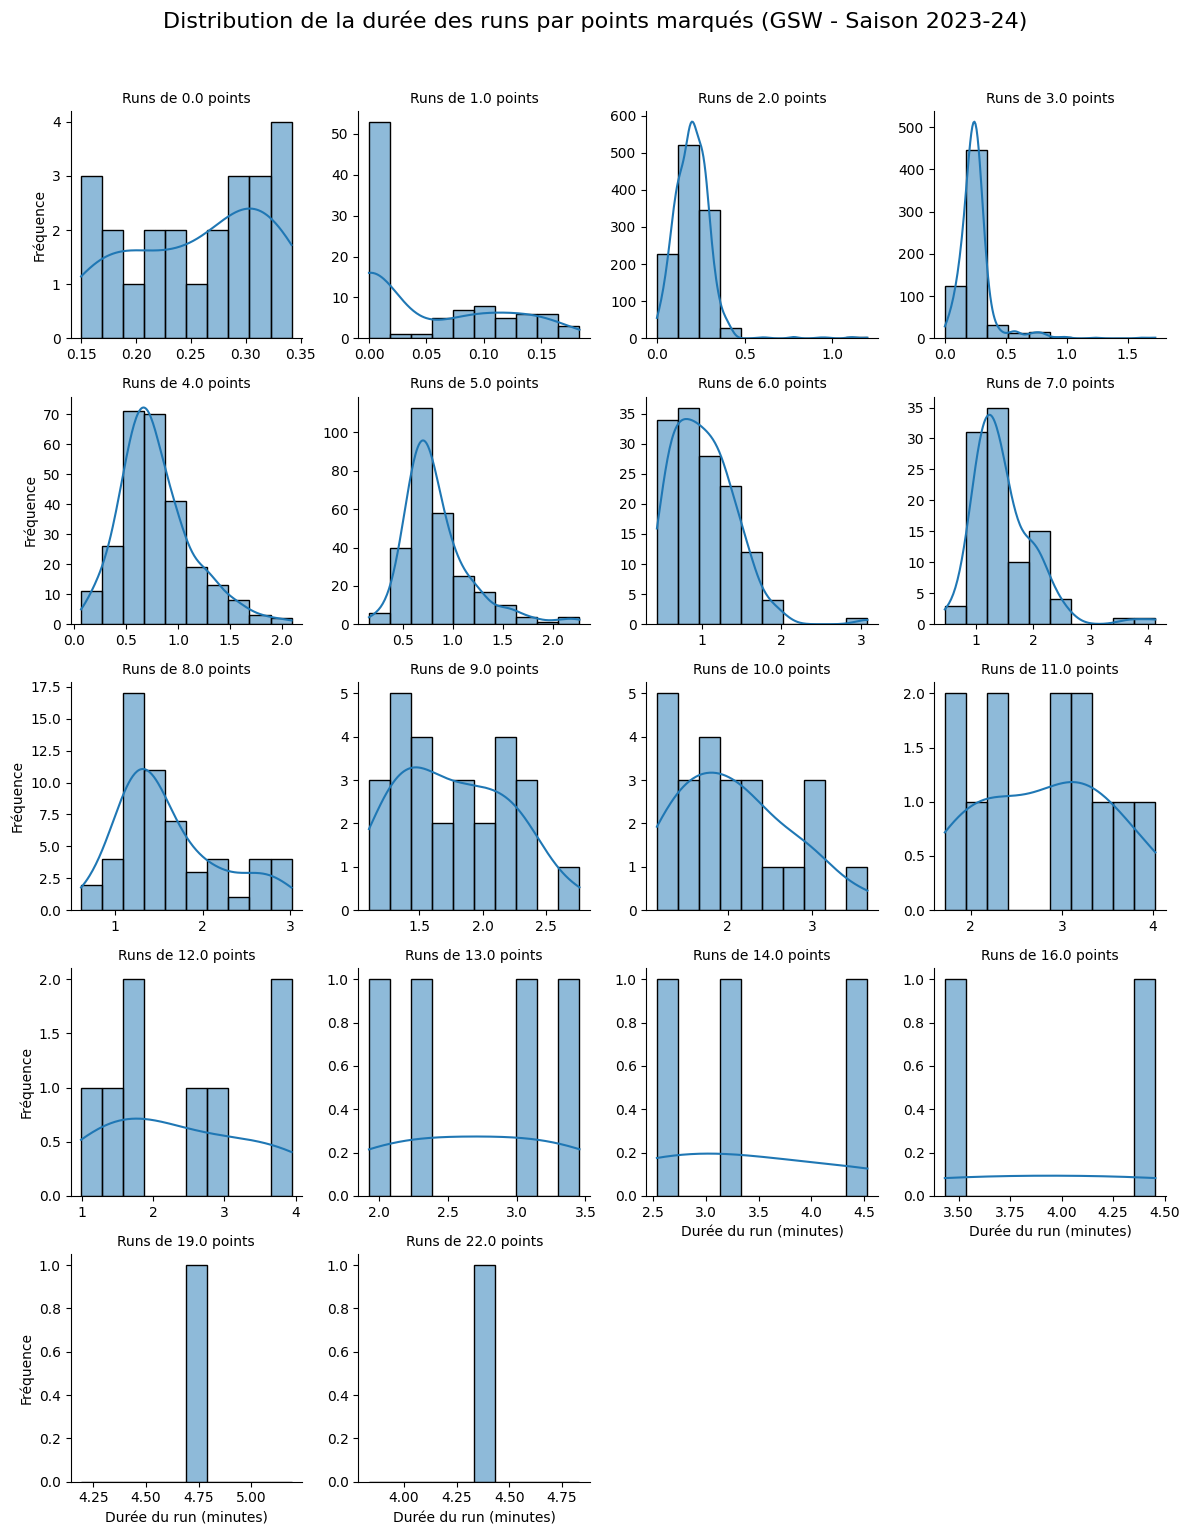

In [30]:
g = sns.FacetGrid(all_raw_runs_gsw_season_sorted, col='pts', col_wrap=4, height=3, sharex=False, sharey=False)
g.map(sns.histplot, 'duration', kde=True, bins=10)
g.set_axis_labels("Durée du run (minutes)", "Fréquence")
g.set_titles("Runs de {col_name} points")
plt.suptitle(f'Distribution de la durée des runs par points marqués (GSW - Saison {season_to_analyze})', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
import pandas as pd

def generate_random_run(season_runs_df: pd.DataFrame) -> tuple:
    """
    Génère aléatoirement un run (points et durée) en se basant sur les distributions
    observées dans le DataFrame de runs d'une saison donnée.

    Args:
        season_runs_df (pd.DataFrame): DataFrame contenant les runs d'une équipe pour une saison,
                                       avec les colonnes 'pts' et 'duration'.

    Returns:
        tuple: Un tuple (points, durée) représentant un run simulé (float, float).
               Retourne (None, None) si le DataFrame est vide ou si aucune durée n'est trouvée
               pour les points échantillonnés.
    """
    if season_runs_df.empty:
        print("Le DataFrame de runs est vide. Impossible de générer un run.")
        return None, None

    # 1. Sélectionner aléatoirement un nombre de points ('pts') en fonction de sa distribution empirique
    # On échantillonne directement à partir de la colonne 'pts' pour conserver la distribution observée.
    sampled_pts = season_runs_df['pts'].sample(n=1, random_state=None).iloc[0]

    # 2. Filtrer les runs avec ce nombre de points
    runs_with_sampled_pts = season_runs_df[season_runs_df['pts'] == sampled_pts]

    if runs_with_sampled_pts.empty:
        # Cela ne devrait théoriquement pas arriver si sampled_pts provient de season_runs_df,
        # mais c'est une sécurité.
        print(f"Aucune durée trouvée pour {sampled_pts} points. Ceci est inattendu.")
        return sampled_pts, None

    # 3. Sélectionner aléatoirement une durée ('duration') parmi ces runs filtrés
    # On échantillonne directement à partir de la colonne 'duration' filtrée.
    sampled_duration = runs_with_sampled_pts['duration'].sample(n=1, random_state=None).iloc[0]

    return sampled_pts, sampled_duration

print("Fonction 'generate_random_run' définie.")

Fonction 'generate_random_run' définie.


In [32]:
# Générer un run aléatoire pour la saison 2023-24
sampled_pts_23_24, sampled_duration_23_24 = generate_random_run(all_raw_runs_gsw_season_sorted)
if sampled_pts_23_24 is not None:
    print(f"Run aléatoire simulé pour la saison {season_to_analyze} : {sampled_pts_23_24:.0f} points, {sampled_duration_23_24:.2f} minutes")

# Générer un run aléatoire pour la saison 2022-23
sampled_pts_22_23, sampled_duration_22_23 = generate_random_run(all_raw_runs_gsw_season_prev_sorted)
if sampled_pts_22_23 is not None:
    print(f"Run aléatoire simulé pour la saison {season_to_analyze_prev} : {sampled_pts_22_23:.0f} points, {sampled_duration_22_23:.2f} minutes")

print("\nNous pouvons appeler cette fonction plusieurs fois pour simuler de nombreux runs et étudier la dynamique de jeu.")

Run aléatoire simulé pour la saison 2023-24 : 2 points, 0.12 minutes
Run aléatoire simulé pour la saison 2022-23 : 5 points, 1.19 minutes

Nous pouvons appeler cette fonction plusieurs fois pour simuler de nombreux runs et étudier la dynamique de jeu.


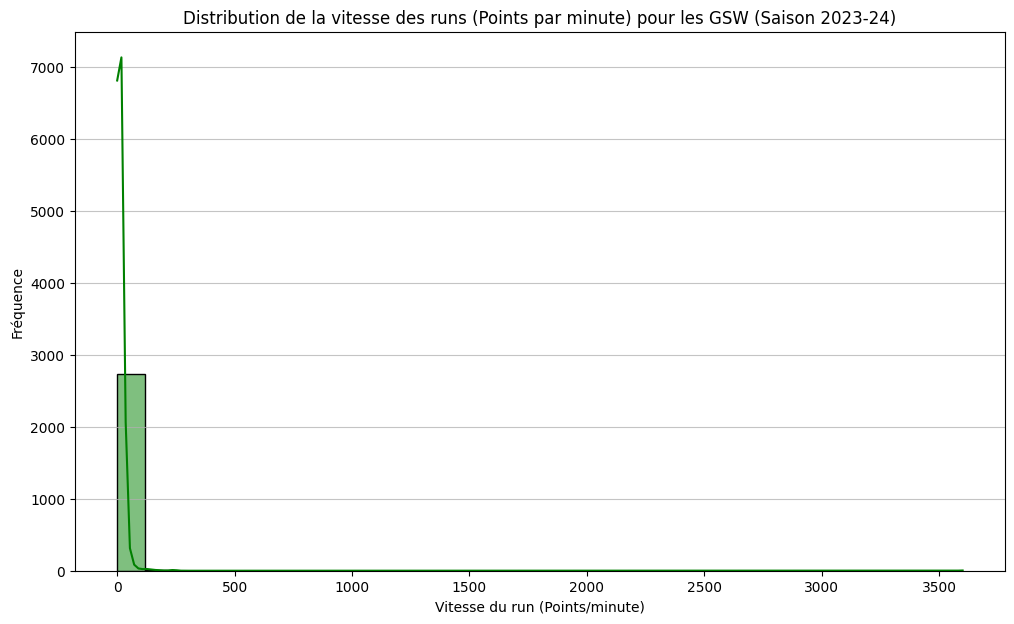

Statistiques descriptives pour la vitesse des runs (Points/minute):
count    2742.000000
mean       13.142798
std        70.018186
min         0.000000
25%         6.315789
50%         9.000000
75%        12.857143
max      3600.000000
Name: speed_pts_per_min, dtype: float64


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer les runs avec une durée de 0 pour éviter la division par zéro
runs_without_zero_duration = all_raw_runs_gsw_season_sorted[
    all_raw_runs_gsw_season_sorted['duration'] > 0
].copy()

# Calculer la vitesse des runs (points par minute)
runs_without_zero_duration['speed_pts_per_min'] = runs_without_zero_duration['pts'] / runs_without_zero_duration['duration']

plt.figure(figsize=(12, 7))
sns.histplot(runs_without_zero_duration['speed_pts_per_min'], bins=30, kde=True, color='green')
plt.title(f'Distribution de la vitesse des runs (Points par minute) pour les GSW (Saison {season_to_analyze})')
plt.xlabel('Vitesse du run (Points/minute)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Statistiques descriptives pour la vitesse des runs (Points/minute):")
print(runs_without_zero_duration['speed_pts_per_min'].describe())

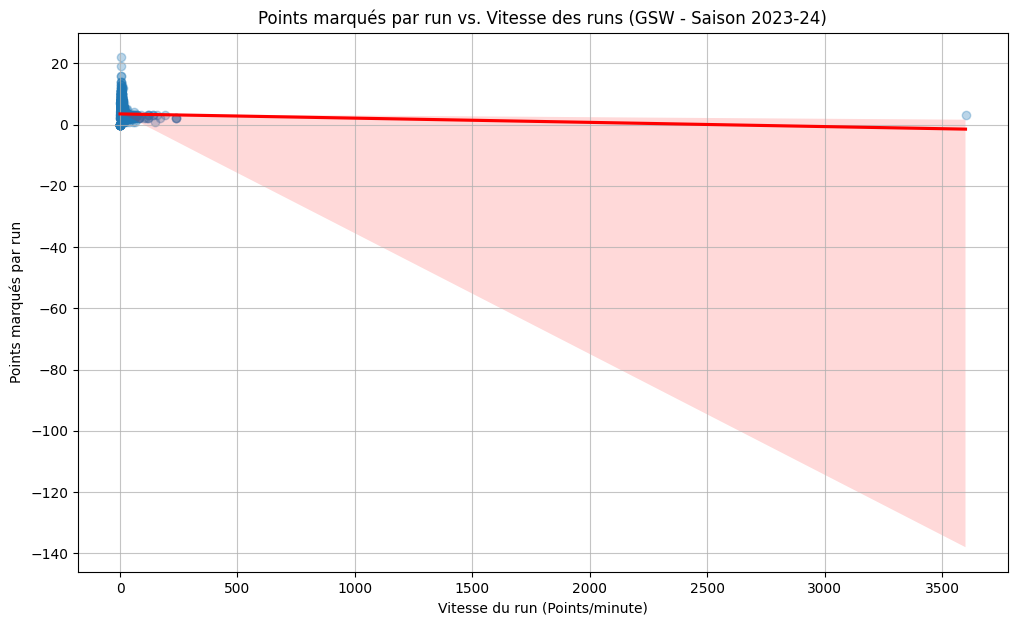

In [34]:
plt.figure(figsize=(12, 7))
sns.regplot(x='speed_pts_per_min', y='pts', data=runs_without_zero_duration,
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Points marqués par run vs. Vitesse des runs (GSW - Saison {season_to_analyze})')
plt.xlabel('Vitesse du run (Points/minute)')
plt.ylabel('Points marqués par run')
plt.grid(axis='both', alpha=0.75)
plt.show()

In [35]:
time.sleep(600)

# Partie IV : Probabilité de Remontada

Récupération des runs pour les Boston Celtics en 2023-24...
Récupération des matchs pour la saison 2023-24 et l'équipe 1610612738...
Traitement du match 1/82: 0022301186...
Nombre d'actions : 476
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 476
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Traitement du match 2/82: 0022301173...
Nombre d'actions : 452
Colonnes disponibles : ['gameId', 'actionN

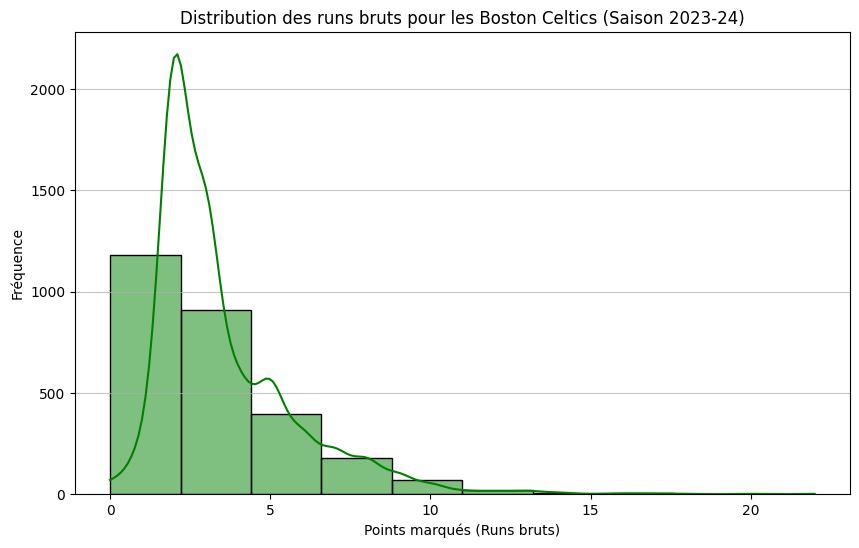

Statistiques descriptives pour les points par run des Boston Celtics:
count    2774.000000
mean        3.523792
std         2.236949
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        22.000000
Name: pts, dtype: float64


In [20]:
# Choisir une autre équipe, par exemple les Boston Celtics
team_id_bos = bos["id"]
team_name_bos = bos["full_name"]

print(f"Récupération des runs pour les {team_name_bos} en {season_to_analyze}...")
all_raw_runs_bos_season, all_weighted_runs_bos_season = get_team_runs_for_season(
    team_id_bos, season_to_analyze
)

print(f"\nNombre total de runs bruts pour les {team_name_bos} en {season_to_analyze} : {len(all_raw_runs_bos_season)}")
print(all_raw_runs_bos_season.head())

# Afficher la distribution des runs bruts pour la nouvelle équipe
plt.figure(figsize=(10, 6))
sns.histplot(all_raw_runs_bos_season['pts'], bins=10, kde=True, color='green')
plt.title(f'Distribution des runs bruts pour les {team_name_bos} (Saison {season_to_analyze})')
plt.xlabel('Points marqués (Runs bruts)')
plt.ylabel('Fréquence')
plt.grid(axis='y', alpha=0.75)
plt.show()

print(f"Statistiques descriptives pour les points par run des {team_name_bos}:")
print(all_raw_runs_bos_season['pts'].describe())

In [23]:
# Ensure the 'duration' column is present and sorted for Boston Celtics' runs
all_raw_runs_bos_season_sorted = all_raw_runs_bos_season.sort_values(by=['gameId', 'start_min']).copy()
# Le calcul de la durée du run est maintenant inclus dans point_filter1.

# Donc, cette ligne n'est plus nécessaire ici.
# all_raw_runs_bos_season_sorted['duration'] = all_raw_runs_bos_season_sorted['end_min'] - all_raw_runs_bos_season_sorted['start_min']

sampled_pts_bos, sampled_duration_bos = generate_random_run(all_raw_runs_bos_season_sorted)
if sampled_pts_bos is not None:
    print(f"Run aléatoire simulé pour les Boston Celtics (Saison {season_to_analyze}) : {sampled_pts_bos:.0f} points, {sampled_duration_bos:.2f} minutes")

Run aléatoire simulé pour les Boston Celtics (Saison 2023-24) : 5 points, 0.61 minutes


In [32]:
import random

def simulate_game(sim_minutes: float, gsw_runs_df: pd.DataFrame, bos_runs_df: pd.DataFrame, team1_name: str, team2_name: str):
    """
    Simule un segment de match entre deux équipes pour un nombre de minutes donné,
    en alternant les runs des deux équipes, avec une gestion spéciale des runs de durée 0.

    Args:
        sim_minutes (float): Le nombre de minutes à simuler.
        gsw_runs_df (pd.DataFrame): DataFrame des runs bruts triés pour la première équipe (GSW).
        bos_runs_df (pd.DataFrame): DataFrame des runs bruts triés pour la deuxième équipe (BOS).
        team1_name (str): Nom/abréviation de la première équipe.
        team2_name (str): Nom/abréviation de la deuxième équipe.

    Returns:
        tuple: (final_score_team1, final_score_team2, event_log_df)
               où event_log_df est un DataFrame des événements de la simulation.
    """
    current_time = 0.0
    score_team1 = 0
    score_team2 = 0
    event_log = []

    # Randomly decide which team starts
    is_team1_turn = random.choice([True, False])

    while current_time < sim_minutes:
        if is_team1_turn:
            current_team_name = team1_name
            current_team_runs_df = gsw_runs_df
        else:
            current_team_name = team2_name
            current_team_runs_df = bos_runs_df

        pts, duration = generate_random_run(current_team_runs_df)

        # Handle zero-duration runs with retry logic
        if duration == 0:
            #print(f"Warning: {current_team_name} generated a 0-duration run. Retrying for the same team.")
            pts_retry, duration_retry = generate_random_run(current_team_runs_df)

            if duration_retry == 0:
                #print(f"Warning: {current_team_name} generated a 0-duration run again. Keeping this run.")
                pts = pts_retry
                duration = duration_retry
            else:
                #print(f"Retry successful for {current_team_name}. Using run with {duration_retry:.2f} minutes.")
                pts = pts_retry
                duration = duration_retry

        if pts is None or duration is None:
            #print(f"Warning: Could not generate a valid run for {current_team_name} after retries. Stopping simulation.")
            break

        # Calculate effective duration to not exceed sim_minutes
        remaining_time_in_sim = sim_minutes - current_time
        effective_duration = min(duration, remaining_time_in_sim)

        # If no effective duration can be added, break the loop
        if effective_duration <= 0 and pts > 0: # Only break if no time is left and points could potentially be scored
            break

        adjusted_pts = pts
        # Adjust points proportionally if the run duration is cut short
        # Only adjust if duration > 0 to avoid division by zero
        if duration > 0 and effective_duration < duration:
            adjusted_pts = round(pts * (effective_duration / duration))

        # Update scores using adjusted points
        if is_team1_turn:
            score_team1 += adjusted_pts
        else:
            score_team2 += adjusted_pts

        # Log the event
        event_log.append({
            'team': current_team_name,
            'points_original': pts,
            'points_adjusted': adjusted_pts,
            'duration_full': duration, # Original duration generated by generate_random_run
            'duration_effective': effective_duration, # Duration actually used in simulation
            'time_start': current_time,
            'time_end': current_time + effective_duration,
            team1_name + '_score_after_run': score_team1,
            team2_name + '_score_after_run': score_team2
        })

        # Advance time using effective duration
        current_time += effective_duration

        # Switch turns
        is_team1_turn = not is_team1_turn

    event_log_df = pd.DataFrame(event_log)
    return score_team1, score_team2, event_log_df

In [33]:
x_minutes = 10

In [36]:
# Execute the simulation for x_minutes
final_gsw_score, final_bos_score, simulation_events = simulate_game(
    x_minutes,
    all_raw_runs_gsw_season_sorted,
    all_raw_runs_bos_season_sorted,
    gsw['abbreviation'], # Use abbreviation for team names in the log
    bos['abbreviation']
)

print(f"Simulation terminée après environ {simulation_events['time_end'].max():.2f} minutes (temps de jeu total accumulé).")
print(f"Score final {gsw['abbreviation']}: {final_gsw_score}")
print(f"Score final {bos['abbreviation']}: {final_bos_score}")

print("\nRésumé des événements (début du match):")
display(simulation_events.head(10))

print("\nRésumé des événements (fin du match):")
display(simulation_events.tail(10))

Simulation terminée après environ 10.00 minutes (temps de jeu total accumulé).
Score final GSW: 36.0
Score final BOS: 32.0

Résumé des événements (début du match):


,team,points_original,points_adjusted,duration_full,duration_effective,time_start,time_end,GSW_score_after_run,BOS_score_after_run
0,BOS,3.0,3.0,0.233333,0.233333,0.000000,0.233333,0.0,3.0
1,GSW,2.0,2.0,0.175000,0.175000,0.233333,0.408333,2.0,3.0
2,BOS,3.0,3.0,0.258333,0.258333,0.408333,0.666667,2.0,6.0
3,GSW,2.0,2.0,0.350000,0.350000,0.666667,1.016667,4.0,6.0
4,BOS,2.0,2.0,0.183333,0.183333,1.016667,1.200000,4.0,8.0
5,GSW,2.0,2.0,0.308333,0.308333,1.200000,1.508333,6.0,8.0
6,BOS,2.0,2.0,0.066667,0.066667,1.508333,1.575000,6.0,10.0
7,GSW,2.0,2.0,0.174167,0.174167,1.575000,1.749167,8.0,10.0
8,BOS,4.0,4.0,0.500000,0.500000,1.749167,2.249167,8.0,14.0
9,GSW,5.0,5.0,0.858333,0.858333,2.249167,3.107500,13.0,14.0



Résumé des événements (fin du match):


,team,points_original,points_adjusted,duration_full,duration_effective,time_start,time_end,GSW_score_after_run,BOS_score_after_run
12,BOS,5.0,5.0,0.783333,0.783333,4.056667,4.840000,16.0,23.0
13,GSW,3.0,3.0,0.183333,0.183333,4.840000,5.023333,19.0,23.0
14,BOS,2.0,2.0,0.741667,0.741667,5.023333,5.765000,19.0,25.0
15,GSW,3.0,3.0,0.095000,0.095000,5.765000,5.860000,22.0,25.0
16,BOS,3.0,3.0,0.250000,0.250000,5.860000,6.110000,22.0,28.0
17,GSW,2.0,2.0,0.208333,0.208333,6.110000,6.318333,24.0,28.0
18,BOS,1.0,1.0,0.075000,0.075000,6.318333,6.393333,24.0,29.0
19,GSW,11.0,11.0,3.132500,3.132500,6.393333,9.525833,35.0,29.0
20,BOS,3.0,3.0,0.336667,0.336667,9.525833,9.862500,35.0,32.0
21,GSW,4.0,1.0,0.483333,0.137500,9.862500,10.000000,36.0,32.0


In [37]:
import random

def simulate_comeback_probability(
    team_A_runs_df: pd.DataFrame,
    team_B_runs_df: pd.DataFrame,
    initial_deficit_A: int,
    minutes_remaining: float,
    num_simulations: int,
    team_A_name: str,
    team_B_name: str
) -> float:
    """
    Calcule empiriquement la probabilité de remontada pour l'équipe A face à l'équipe B,
    lorsque l'équipe A est menée de `initial_deficit_A` points et qu'il reste `minutes_remaining`.

    Args:
        team_A_runs_df (pd.DataFrame): DataFrame des runs de l'équipe A (celle qui tente la remontada).
        team_B_runs_df (pd.DataFrame): DataFrame des runs de l'équipe B (celle qui mène).
        initial_deficit_A (int): Nombre de points dont l'équipe A est menée.
        minutes_remaining (float): Nombre de minutes restantes à simuler.
        num_simulations (int): Nombre de simulations à effectuer.
        team_A_name (str): Nom/abréviation de l'équipe A.
        team_B_name (str): Nom/abréviation de l'équipe B.

    Returns:
        float: La probabilité empirique que l'équipe A fasse une remontada.
    """

    comeback_count = 0
    print(f"Début de {num_simulations} simulations pour la probabilité de remontada...")

    for i in range(num_simulations):
        if (i + 1) % (num_simulations // 10) == 0 or i == 0 or i == num_simulations - 1:
            print(f"  Simulation {i+1}/{num_simulations}...")

        # Simuler les points marqués par chaque équipe pendant les minutes restantes
        # On assume un score initial arbitraire pour faciliter le calcul du delta.
        # Par exemple, si A est menée de N points, on peut considérer que le score avant simulation est
        # B: 100, A: 100 - N
        # La fonction simulate_game simule juste les points marqués P_A et P_B durant les minutes restantes.
        # La condition de comeback est alors (100 - N + P_A) > (100 + P_B)
        # Ce qui équivaut à P_A > (N + P_B)

        simulated_points_A, simulated_points_B, _ = simulate_game(
            minutes_remaining,
            team_A_runs_df,
            team_B_runs_df,
            team_A_name,
            team_B_name
        )

        # Vérifier si l'équipe A a réussi la remontada
        if (simulated_points_A - initial_deficit_A) > simulated_points_B:
            comeback_count += 1

    probability = comeback_count / num_simulations
    return probability

# Exemple d'utilisation :
# Supposons que les GSW (Team A) sont menés de 15 points par les Celtics (Team B)
# et qu'il reste 12 minutes à jouer.

initial_deficit = 15 # Points dont l'équipe A est menée
minutes_left = 12   # Minutes restantes dans le match
num_sims = 1000     # Nombre de simulations pour estimer la probabilité

# Maintenant, les Boston Celtics sont l'équipe A (celle qui tente la remontada)
# et les Golden State Warriors sont l'équipe B (celle qui mène)
prob_remontada_bos = simulate_comeback_probability(
    team_A_runs_df=all_raw_runs_bos_season_sorted,  # Celtics comme Team A
    team_B_runs_df=all_raw_runs_gsw_season_sorted,  # Warriors comme Team B
    initial_deficit_A=initial_deficit,
    minutes_remaining=minutes_left,
    num_simulations=num_sims,
    team_A_name=bos['abbreviation'], # Nom des Celtics
    team_B_name=gsw['abbreviation']  # Nom des Warriors
)

print(f"\nProbabilité empirique que les {bos['full_name']} fassent une remontada (menés de {initial_deficit} points, {minutes_left} min restantes) : {prob_remontada_bos:.4f}")


Début de 1000 simulations pour la probabilité de remontada...
  Simulation 1/1000...
  Simulation 100/1000...
  Simulation 200/1000...
  Simulation 300/1000...
  Simulation 400/1000...
  Simulation 500/1000...
  Simulation 600/1000...
  Simulation 700/1000...
  Simulation 800/1000...
  Simulation 900/1000...
  Simulation 1000/1000...

Probabilité empirique que les Boston Celtics fassent une remontada (menés de 15 points, 12 min restantes) : 0.0740


In [43]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

# Définir les plages pour les minutes restantes et le déficit initial
minutes_range = np.arange(5, 10, 0.1)  # De 5 à 20 minutes par pas de 1
deficit_range = np.arange(5, 26, 5)  # De 5 à 25 points par pas de 5
num_sims_for_plot = 100  # Réduire le nombre de simulations pour le plot 3D afin de limiter le temps d'exécution

results = []
print("Début de la collecte de données pour le plot 3D...")

for minutes in minutes_range:
    for deficit in deficit_range:
        print(f"  Simulating for {minutes} min remaining, {deficit} pts deficit...")
        prob = simulate_comeback_probability(
            team_A_runs_df=all_raw_runs_bos_season_sorted,
            team_B_runs_df=all_raw_runs_gsw_season_sorted,
            initial_deficit_A=deficit,
            minutes_remaining=minutes,
            num_simulations=num_sims_for_plot,
            team_A_name=bos['abbreviation'],
            team_B_name=gsw['abbreviation']
        )
        results.append({
            'minutes_remaining': minutes,
            'initial_deficit': deficit,
            'comeback_probability': prob
        })

df_3d_plot_data = pd.DataFrame(results)

print("Collecte de données terminée.")
display(df_3d_plot_data.head())


Début de la collecte de données pour le plot 3D...
  Simulating for 5.0 min remaining, 5 pts deficit...
Début de 100 simulations pour la probabilité de remontada...
  Simulation 1/100...
  Simulation 10/100...
  Simulation 20/100...
  Simulation 30/100...
  Simulation 40/100...
  Simulation 50/100...
  Simulation 60/100...
  Simulation 70/100...
  Simulation 80/100...
  Simulation 90/100...
  Simulation 100/100...
  Simulating for 5.0 min remaining, 10 pts deficit...
Début de 100 simulations pour la probabilité de remontada...
  Simulation 1/100...
  Simulation 10/100...
  Simulation 20/100...
  Simulation 30/100...
  Simulation 40/100...
  Simulation 50/100...
  Simulation 60/100...
  Simulation 70/100...
  Simulation 80/100...
  Simulation 90/100...
  Simulation 100/100...
  Simulating for 5.0 min remaining, 15 pts deficit...
Début de 100 simulations pour la probabilité de remontada...
  Simulation 1/100...
  Simulation 10/100...
  Simulation 20/100...
  Simulation 30/100...
  Simula

,minutes_remaining,initial_deficit,comeback_probability
0,5.0,5,0.15
1,5.0,10,0.05
2,5.0,15,0.00
3,5.0,20,0.00
4,5.0,25,0.00


In [44]:
display(df_3d_plot_data)

,minutes_remaining,initial_deficit,comeback_probability
0,5.0,5,0.15
1,5.0,10,0.05
2,5.0,15,0.00
3,5.0,20,0.00
4,5.0,25,0.00
...,...,...,...
245,9.9,5,0.32
246,9.9,10,0.13
247,9.9,15,0.07
248,9.9,20,0.04


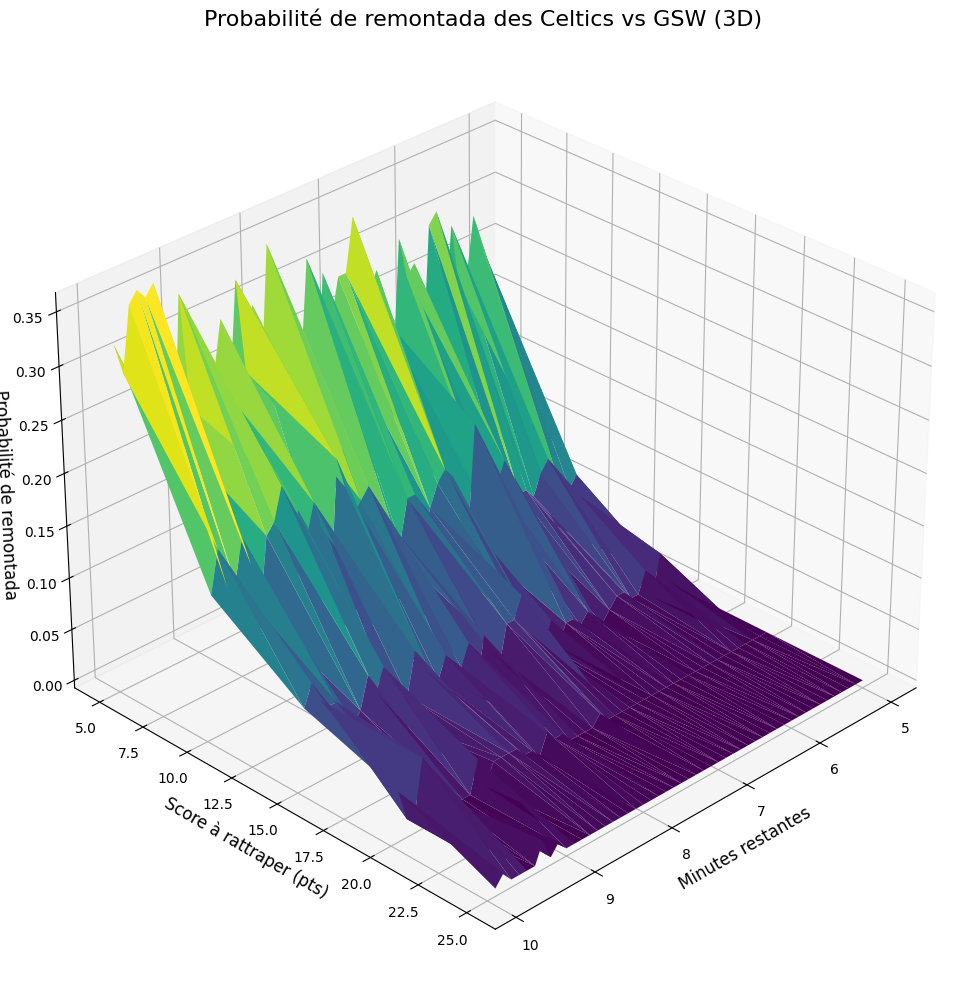

In [45]:
# Préparer les données pour le plot 3D
X = df_3d_plot_data['minutes_remaining'].values
Y = df_3d_plot_data['initial_deficit'].values
Z = df_3d_plot_data['comeback_probability'].values

# Créer le plot 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Utiliser un scatter plot ou une surface de triangulation si les données ne sont pas sur une grille parfaite
# Si les données sont sur une grille (ce qui est le cas ici), on peut les remodeler pour une surface

# Pour une surface de triangulation (plus flexible pour les données non-uniformes)
ax.plot_trisurf(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel('Minutes restantes', fontsize=12)
ax.set_ylabel('Score à rattraper (pts)', fontsize=12)
ax.set_zlabel('Probabilité de remontada', fontsize=12)
ax.set_title('Probabilité de remontada des Celtics vs GSW (3D)', fontsize=16)

# Rotation du graphique pour une meilleure vue (par exemple, élévation=30 degrés, azimut=45 degrés)
ax.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()